In [11]:
# %% [markdown]
# # L0 Model Deep Dive: Performance, Calibration, and Elite Selection Analysis
# **Data Source:** Focused L0 OOF Predictions (Poisson, Gradient Boosting, Enhanced Monte Carlo - PCA without Odds)
#
# **Objective:**
# 1. Evaluate and compare the performance of each L0 model across all relevant betting markets.
# 2. Analyze probability calibration for each model-market pair.
# 3. Identify optimal probability thresholds for each model-market to achieve desired actual win rates.
# 4. Determine the most "efficient" selections (market-model-threshold combinations) for potential parlay inclusion or as strong features for a stacker model.
# 5. Generate insights to guide further L0 model refinement or stacker design.

# %%
# --- Core Imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from typing import List, Dict, Tuple, Any, Optional

# --- Sklearn Metrics & Calibration ---
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve

# --- Notebook Configuration & Styling ---
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis") # Or your preferred palette
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 1000)

# --- Paths & Constants ---
# *** USER TO VERIFY ALL PATHS ***
BASE_DIR = Path("/Users/barroca888/Downloads/Agenticfc/AgenticFC888") # Adjust as needed
oof_file_path = BASE_DIR / "models/data/outputs/level0_oof_predictions_pca_L0_focused_without_odds.parquet"
# MARKET_DEFINITIONS_PATH = BASE_DIR / "models/utils/files/parlay_market_definitions.json" # If needed for target generation logic
FEATURE_CONFIG_PATH = BASE_DIR / "models/utils/features.py" # Path to your feature config, if needed for target col names

NOTEBOOK_OUTPUT_DIR = BASE_DIR / "notebook_outputs/L0_focused_model_nonpca_analysis"
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Define paths for OOT analysis files
PATH_OOT_PCA_CSV = NOTEBOOK_OUTPUT_DIR / "final_best_oot_selections_PCA.csv"
PATH_OOT_NONPCA_CSV = NOTEBOOK_OUTPUT_DIR / "final_best_oot_selections_nonPCA.csv"

# Model prefixes as they appear in your OOF file (e.g., after generate_oof_predictions.py)
MODEL_PREFIXES = [
    "poisson_pca_without_odds",
    "gradient_boosting_pca_without_odds",
    "monte_carlo_enhanced_pca_without_odds"
]

# Target columns present in the OOF file (actual outcomes of matches)
# These are the raw outcomes from which specific market outcomes will be derived
RAW_TARGET_COLS = ['FTHG', 'FTAG', 'FTR'] # Example, adjust to your OOF file
MATCH_ID_COL = 'MatchID'
DATE_COL = 'Date'

# Core probability suffixes (the part after "model_prefix_") that we want to analyze
# This list should be comprehensive, matching your `calculate_poisson_outcome_probs` output
# and your `CORE_PREDICTION_KEYS` from `generate_oof_predictions.py` (excluding 'expected_HG'/'AG')
CORE_PROBABILITY_SUFFIXES: List[str] = [
    'prob_H', 'prob_D', 'prob_A', 'prob_1X', 'prob_12', 'prob_X2',
    'prob_O15', 'prob_U15', 'prob_O25', 'prob_U25', 'prob_O35', 'prob_U35', 'prob_O45', 'prob_U45', # Added O45/U45
    'prob_BTTS_Y', 'prob_BTTS_N',
    'prob_goals_0_1', 'prob_goals_2_3', 'prob_goals_2_4', 'prob_goals_3_plus', # O25
    'prob_H_and_O15', 'prob_D_and_O15', 'prob_A_and_O15', 'prob_H_and_U15', 'prob_D_and_U15', 'prob_A_and_U15',
    'prob_H_and_O25', 'prob_D_and_O25', 'prob_A_and_O25', 'prob_H_and_U25', 'prob_D_and_U25', 'prob_A_and_U25',
    'prob_H_and_O35', 'prob_D_and_O35', 'prob_A_and_O35', 'prob_H_and_U35', 'prob_D_and_U35', 'prob_A_and_U35',
    'prob_H_and_O45', 'prob_D_and_O45', 'prob_A_and_O45', 'prob_H_and_U45', 'prob_D_and_U45', 'prob_A_and_U45',
    'prob_1X_and_O15', 'prob_12_and_O15', 'prob_X2_and_O15', 'prob_1X_and_U15', 'prob_12_and_U15', 'prob_X2_and_U15',
    'prob_1X_and_O25', 'prob_12_and_O25', 'prob_X2_and_O25', 'prob_1X_and_U25', 'prob_12_and_U25', 'prob_X2_and_U25',
    'prob_1X_and_O35', 'prob_12_and_O35', 'prob_X2_and_O35', 'prob_1X_and_U35', 'prob_12_and_U35', 'prob_X2_and_U35',
    'prob_1X_and_O45', 'prob_12_and_O45', 'prob_X2_and_O45', 'prob_1X_and_U45', 'prob_12_and_U45', 'prob_X2_and_U45',
    'prob_H_and_BTTS_Y', 'prob_D_and_BTTS_Y', 'prob_A_and_BTTS_Y',
    'prob_H_and_BTTS_N', 'prob_D_and_BTTS_N', 'prob_A_and_BTTS_N',
    'prob_1X_and_BTTS_Y', 'prob_12_and_BTTS_Y', 'prob_X2_and_BTTS_Y',
    'prob_1X_and_BTTS_N', 'prob_12_and_BTTS_N', 'prob_X2_and_BTTS_N',
    'prob_O25_and_BTTS_Y', 'prob_O25_and_BTTS_N',
    'prob_O35_and_BTTS_Y', 'prob_O35_and_BTTS_N',
    # Add any other duals your calculate_poisson_outcome_probs generates
]

# Minimum number of samples for a group/bin to be considered in plots/analysis
MIN_SAMPLES_FOR_STAT = 50
MIN_SAMPLES_FOR_BIN = 20

print("Notebook Setup Complete.")

Notebook Setup Complete.


In [12]:
# %% [markdown]
# ## 1. Data Loading and Target Generation
#
# Load the L0 OOF predictions and generate the actual outcome (0/1) columns for all markets we want to analyze.

# %%
# --- Load OOF Data ---
assert oof_file_path.exists(), f"OOF file not found: {oof_file_path}"
oof_df = pd.read_parquet(oof_file_path)
print(f"Loaded OOF data: {oof_df.shape}")
oof_df.info()
print(oof_df.head())

# --- Helper Function to Derive Actual Outcomes ---
# (This function needs to be robust and cover all CORE_PROBABILITY_SUFFIXES)
def derive_actual_market_outcomes(df: pd.DataFrame, prob_suffixes: List[str], fthg_col: str, ftag_col: str, ftr_col: str) -> pd.DataFrame:
    """
    Derives binary (0/1) actual outcomes for a list of market probability suffixes.
    """
    df_out = df.copy()
    for suffix in prob_suffixes:
        actual_col_name = f"actual_{suffix.replace('prob_', '')}"
        
        # Single Outcomes
        if suffix == 'prob_H': 
            df_out[actual_col_name] = (df_out[ftr_col] == 'H').astype(int)
        elif suffix == 'prob_D': 
            df_out[actual_col_name] = (df_out[ftr_col] == 'D').astype(int)
        elif suffix == 'prob_A': 
            df_out[actual_col_name] = (df_out[ftr_col] == 'A').astype(int)
        elif suffix == 'prob_1X': 
            df_out[actual_col_name] = ((df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'D')).astype(int)
        elif suffix == 'prob_12': 
            df_out[actual_col_name] = ((df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'A')).astype(int)
        elif suffix == 'prob_X2': 
            df_out[actual_col_name] = ((df_out[ftr_col] == 'D') | (df_out[ftr_col] == 'A')).astype(int)
        elif suffix == 'prob_BTTS_Y': 
            df_out[actual_col_name] = ((df_out[fthg_col] > 0) & (df_out[ftag_col] > 0)).astype(int)
        elif suffix == 'prob_BTTS_N': 
            df_out[actual_col_name] = (~((df_out[fthg_col] > 0) & (df_out[ftag_col] > 0))).astype(int)
        # Over/Under (add all relevant lines, e.g. O05, U05, O45, U45 if in CORE_PROBABILITY_SUFFIXES)
        elif suffix == 'prob_O15': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 1.5).astype(int)
        elif suffix == 'prob_U15': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 1.5).astype(int)
        elif suffix == 'prob_O25': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 2.5).astype(int)
        elif suffix == 'prob_U25': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 2.5).astype(int)
        elif suffix == 'prob_O35': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 3.5).astype(int)
        elif suffix == 'prob_U35': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 3.5).astype(int)
        elif suffix == 'prob_O45': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 4.5).astype(int)
        elif suffix == 'prob_U45': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] <= 4.5).astype(int)
        # Goal Bands
        elif suffix == 'prob_goals_0_1': 
            df_out[actual_col_name] = ((df_out[fthg_col] + df_out[ftag_col] >=0) & (df_out[fthg_col] + df_out[ftag_col] <=1)).astype(int)
        elif suffix == 'prob_goals_2_3': 
            df_out[actual_col_name] = ((df_out[fthg_col] + df_out[ftag_col] >=2) & (df_out[fthg_col] + df_out[ftag_col] <=3)).astype(int)
        elif suffix == 'prob_goals_2_4': 
            df_out[actual_col_name] = ((df_out[fthg_col] + df_out[ftag_col] >=2) & (df_out[fthg_col] + df_out[ftag_col] <=4)).astype(int)
        elif suffix == 'prob_goals_3_plus': 
            df_out[actual_col_name] = (df_out[fthg_col] + df_out[ftag_col] > 2.5).astype(int) # Same as O2.5
        
        # Combo Bets (Example for H_and_O25, expand for all in CORE_PROBABILITY_SUFFIXES)
        # This requires careful parsing of the suffix string
        elif '_and_' in suffix:
            parts = suffix.replace('prob_', '').split('_and_')
            market1_str, market2_str = parts[0], parts[1]
            
            # Determine outcome for market1
            outcome1 = pd.Series(False, index=df_out.index)
            if market1_str == 'H': 
                outcome1 = df_out[ftr_col] == 'H'
            elif market1_str == 'D': 
                outcome1 = df_out[ftr_col] == 'D'
            elif market1_str == 'A': 
                outcome1 = df_out[ftr_col] == 'A'
            elif market1_str == '1X': 
                outcome1 = (df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'D')
            elif market1_str == '12': 
                outcome1 = (df_out[ftr_col] == 'H') | (df_out[ftr_col] == 'A')
            elif market1_str == 'X2': 
                outcome1 = (df_out[ftr_col] == 'D') | (df_out[ftr_col] == 'A')
            elif market1_str == 'O15': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 1.5
            elif market1_str == 'U15': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 1.5
            elif market1_str == 'O25': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 2.5
            elif market1_str == 'U25': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 2.5
            elif market1_str == 'O35': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 3.5
            elif market1_str == 'U35': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 3.5
            elif market1_str == 'O45': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) > 4.5
            elif market1_str == 'U45': 
                outcome1 = (df_out[fthg_col] + df_out[ftag_col]) <= 4.5

            # Determine outcome for market2
            outcome2 = pd.Series(False, index=df_out.index)
            if market2_str == 'O15': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 1.5
            elif market2_str == 'U15': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 1.5
            elif market2_str == 'O25': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 2.5
            elif market2_str == 'U25': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 2.5
            elif market2_str == 'O35': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 3.5
            elif market2_str == 'U35': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 3.5
            elif market2_str == 'O45': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) > 4.5
            elif market2_str == 'U45': 
                outcome2 = (df_out[fthg_col] + df_out[ftag_col]) <= 4.5
            elif market2_str == 'BTTS_Y': 
                outcome2 = (df_out[fthg_col] > 0) & (df_out[ftag_col] > 0)
            elif market2_str == 'BTTS_N': 
                outcome2 = ~((df_out[fthg_col] > 0) & (df_out[ftag_col] > 0))

            df_out[actual_col_name] = (outcome1 & outcome2).astype(int)
        else:
            print(f"Warning: No logic to derive actual outcome for market suffix: {suffix}")
            df_out[actual_col_name] = np.nan # Mark as not derivable for now
            
    return df_out

# --- Generate Actual Outcome Columns ---
# Make sure FTHG, FTAG, FTR column names match your OOF file exactly
oof_df_with_actuals = derive_actual_market_outcomes(oof_df, CORE_PROBABILITY_SUFFIXES, 'FTHG', 'FTAG', 'FTR')
print(f"\nAdded actual outcome columns. New shape: {oof_df_with_actuals.shape}")
print("Sample of added actual columns:")
print(oof_df_with_actuals[[col for col in oof_df_with_actuals.columns if col.startswith('actual_')]].head())

Loaded OOF data: (109761, 255)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109761 entries, 0 to 109760
Columns: 255 entries, MatchID to monte_carlo_enhanced_pca_without_odds_prob_O35_and_BTTS_N
dtypes: Int8(2), category(1), datetime64[ns](1), float64(250), string(1)
memory usage: 211.6 MB
                               MatchID       Date  FTHG  FTAG FTR  poisson_pca_without_odds_expected_HG  poisson_pca_without_odds_expected_AG  poisson_pca_without_odds_prob_H  poisson_pca_without_odds_prob_D  poisson_pca_without_odds_prob_A  poisson_pca_without_odds_prob_1X  poisson_pca_without_odds_prob_12  poisson_pca_without_odds_prob_X2  poisson_pca_without_odds_prob_O15  poisson_pca_without_odds_prob_U15  poisson_pca_without_odds_prob_O25  poisson_pca_without_odds_prob_U25  poisson_pca_without_odds_prob_O35  poisson_pca_without_odds_prob_U35  poisson_pca_without_odds_prob_BTTS_Y  poisson_pca_without_odds_prob_BTTS_N  poisson_pca_without_odds_prob_goals_0_1  poisson_pca_without_odds_prob_goa

In [13]:
# %% [markdown]
# ## 3. Market-by-Market Performance Analysis
#
# For each model and each market:
# - Calculate overall performance metrics (Log-Loss, Brier Score, AUC where applicable).
# - Plot calibration curves.
# - Analyze actual win rate vs. binned predicted probability (Threshold Analysis).

# %%
# --- Function to Evaluate a Single Model-Market Pair ---
def evaluate_model_market(
    df: pd.DataFrame,
    model_prefix: str,
    market_suffix: str, # e.g., 'prob_H', 'prob_O25'
    actual_col_suffix: str, # e.g., 'H', 'O25' (without 'actual_')
    min_samples_stat: int = MIN_SAMPLES_FOR_STAT,
    min_samples_bin: int = MIN_SAMPLES_FOR_BIN
) -> Optional[pd.DataFrame]:
    """
    Evaluates a single model-market pair, returns binned performance.
    """
    prob_col = f"{model_prefix}_{market_suffix}"
    actual_col = f"actual_{actual_col_suffix}"

    if prob_col not in df.columns or actual_col not in df.columns:
        # logger.warning(f"Skipping {market_suffix} for {model_prefix}: Columns missing.")
        return None

    data = df[[prob_col, actual_col]].dropna()
    if len(data) < min_samples_stat:
        # logger.info(f"Skipping {market_suffix} for {model_prefix}: Insufficient samples ({len(data)} < {min_samples_stat}).")
        return None

    y_true = data[actual_col]
    y_prob = data[prob_col]

    # Ensure probabilities are clipped for metric calculations
    y_prob_clipped = np.clip(y_prob, 1e-15, 1 - 1e-15)

    try:
        logloss = log_loss(y_true, y_prob_clipped)
        brier = brier_score_loss(y_true, y_prob)
        auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    except ValueError as e:
        # print(f"Could not calculate metrics for {model_prefix} - {market_suffix}: {e}")
        logloss, brier, auc = np.nan, np.nan, np.nan

    print(f"\n--- Model: {model_prefix}, Market: {market_suffix} ---")
    print(f"  Samples: {len(data)}")
    print(f"  Log-Loss: {logloss:.4f}, Brier Score: {brier:.4f}, AUC: {auc:.4f}")

    # Calibration Curve Plot
    plt.figure(figsize=(7, 5))
    fraction_of_positives, mean_predicted_value = calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform')
    plt.plot(mean_predicted_value, fraction_of_positives, "s-", label=model_prefix)
    plt.plot([0, 1], [0, 1], "k:", label="Perfectly calibrated")
    plt.xlabel("Mean Predicted Probability")
    plt.ylabel("Fraction of Positives")
    plt.title(f"Calibration: {market_suffix} by {model_prefix}")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(NOTEBOOK_OUTPUT_DIR / f"calibration_{model_prefix}_{market_suffix.replace('prob_', '')}.png")
    # plt.show() # Can be noisy for many plots
    plt.close()

    # Binned Performance Analysis
    binned_data = []
    threshold_bins = np.arange(0.0, 1.01, 0.05) # More granular bins if needed
    for i in range(len(threshold_bins) - 1):
        lower = threshold_bins[i]
        upper = threshold_bins[i+1]
        mask = (y_prob >= lower) & (y_prob < upper)
        if mask.sum() >= min_samples_bin:
            binned_data.append({
                'model': model_prefix,
                'market_suffix': market_suffix,
                'prob_bin_label': f"[{lower:.2f}-{upper:.2f})",
                'prob_bin_mid': (lower + upper) / 2,
                'num_bets': mask.sum(),
                'actual_win_rate_pct': y_true[mask].mean() * 100,
                'avg_pred_prob': y_prob[mask].mean()
            })
    if not binned_data: return None
    return pd.DataFrame(binned_data)

# --- Loop through models and markets ---
all_binned_performances_list = []
for model_prefix_iter in MODEL_PREFIXES:
    for market_prob_suffix_iter in CORE_PROBABILITY_SUFFIXES:
        market_actual_suffix_iter = market_prob_suffix_iter.replace('prob_', '')
        binned_df = evaluate_model_market(
            oof_df_with_actuals,
            model_prefix_iter,
            market_prob_suffix_iter,
            market_actual_suffix_iter
        )
        if binned_df is not None:
            all_binned_performances_list.append(binned_df)

if all_binned_performances_list:
    master_binned_perf_df = pd.concat(all_binned_performances_list, ignore_index=True)
    print("\n\n--- Master Binned Performance Table (Sample) ---")
    print(master_binned_perf_df.head())
    master_binned_perf_df.to_csv(NOTEBOOK_OUTPUT_DIR / "master_L0_binned_market_performance.csv", index=False)
else:
    print("No binned performance data was generated for any model-market pair.")
    master_binned_perf_df = pd.DataFrame() # Ensure it exists for next cells


--- Model: poisson_pca_without_odds, Market: prob_H ---
  Samples: 109761
  Log-Loss: 0.6467, Brier Score: 0.2278, AUC: 0.6559

--- Model: poisson_pca_without_odds, Market: prob_D ---
  Samples: 109761
  Log-Loss: 0.5526, Brier Score: 0.1834, AUC: 0.5508

--- Model: poisson_pca_without_odds, Market: prob_A ---
  Samples: 109761
  Log-Loss: 0.5833, Brier Score: 0.1989, AUC: 0.6648

--- Model: poisson_pca_without_odds, Market: prob_1X ---
  Samples: 109761
  Log-Loss: 0.5833, Brier Score: 0.1989, AUC: 0.6648

--- Model: poisson_pca_without_odds, Market: prob_12 ---
  Samples: 109761
  Log-Loss: 0.5526, Brier Score: 0.1834, AUC: 0.5508

--- Model: poisson_pca_without_odds, Market: prob_X2 ---
  Samples: 109761
  Log-Loss: 0.6467, Brier Score: 0.2278, AUC: 0.6559

--- Model: poisson_pca_without_odds, Market: prob_O15 ---
  Samples: 109761
  Log-Loss: 0.5479, Brier Score: 0.1816, AUC: 0.5746

--- Model: poisson_pca_without_odds, Market: prob_U15 ---
  Samples: 109761
  Log-Loss: 0.5479, Br



--- Suggested Elite Thresholds (Lowest prob_bin achieving >= 71.0% WR with >= 1000 bets) ---
                                      model    market_suffix prob_bin_label  num_bets  actual_win_rate_pct  avg_pred_prob
1764  monte_carlo_enhanced_pca_without_odds          prob_12    [0.70-0.75)     50663            75.149517       0.735671
922      gradient_boosting_pca_without_odds          prob_12    [0.70-0.75)     50656            72.858102       0.735679
66                 poisson_pca_without_odds          prob_12    [0.70-0.75)     48912            72.759241       0.736717
1296     gradient_boosting_pca_without_odds  prob_12_and_O15    [0.70-0.75)      2893            73.245766       0.721087
447                poisson_pca_without_odds  prob_12_and_O15    [0.70-0.75)      2811            72.572038       0.721252
915      gradient_boosting_pca_without_odds          prob_1X    [0.70-0.75)     19780            74.074823       0.724409
59                 poisson_pca_without_odds        

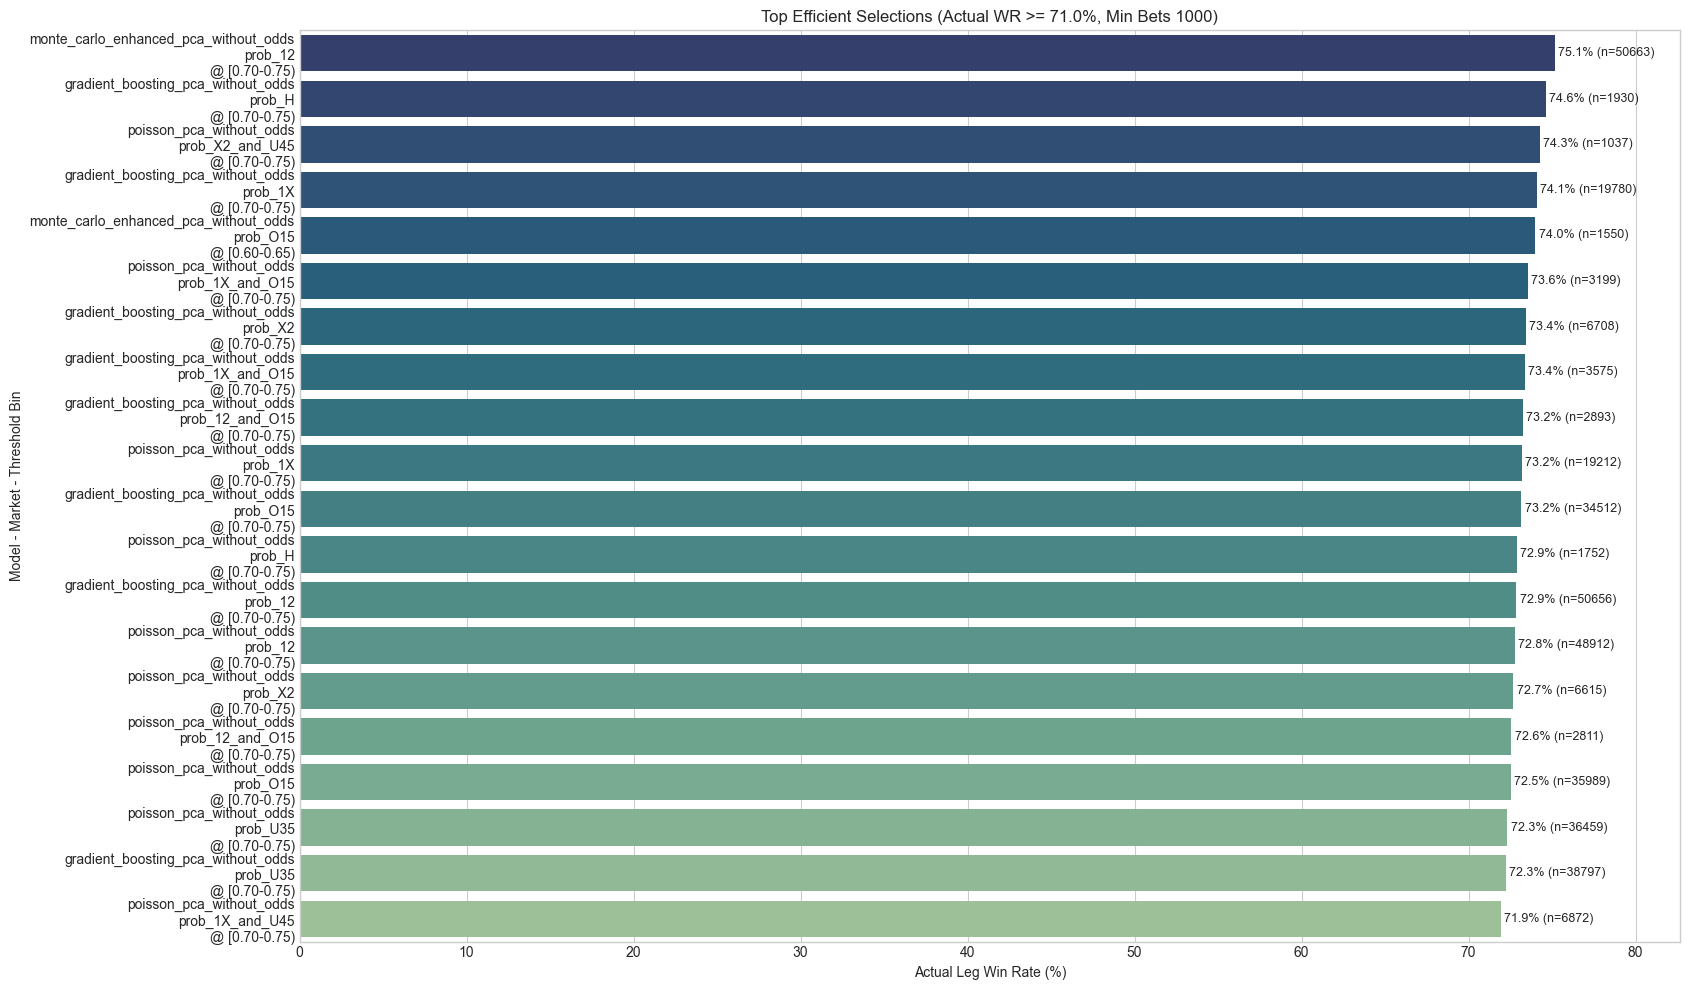

In [14]:
# %% [markdown]
# ## 4. Identifying Efficient Selections and Optimal Thresholds
#
# Using the binned performance data, we identify market-model combinations
# and probability thresholds that yield high actual win rates with sufficient samples.

# %%
if not master_binned_perf_df.empty:
    # --- Define Target Win Rate for "Elite" Selections ---
    TARGET_ACTUAL_LEG_WIN_RATE = 71.0 # Example: aim for legs that actually win >= 70%
    MIN_BETS_FOR_ELITE_THRESHOLD = 1000 # Min bets in a bin to consider its threshold reliable

    efficient_thresholds = master_binned_perf_df[
        (master_binned_perf_df['actual_win_rate_pct'] >= TARGET_ACTUAL_LEG_WIN_RATE) &
        (master_binned_perf_df['num_bets'] >= MIN_BETS_FOR_ELITE_THRESHOLD)
    ]

    # For each model-market, find the lowest probability bin start (threshold) that meets the criteria
    # This prob_bin_mid is the average predicted probability in that bin.
    # We want the 'prob_bin_label' or 'prob_bin_mid' as the threshold.
    
    best_thresholds_per_model_market = efficient_thresholds.loc[
        efficient_thresholds.groupby(['model', 'market_suffix'])['prob_bin_mid'].idxmin()
    ]
    best_thresholds_per_model_market = best_thresholds_per_model_market.sort_values(
        by=['market_suffix', 'actual_win_rate_pct'], ascending=[True, False]
    )

    print(f"\n\n--- Suggested Elite Thresholds (Lowest prob_bin achieving >= {TARGET_ACTUAL_LEG_WIN_RATE}% WR with >= {MIN_BETS_FOR_ELITE_THRESHOLD} bets) ---")
    print(best_thresholds_per_model_market[['model', 'market_suffix', 'prob_bin_label', 'num_bets', 'actual_win_rate_pct', 'avg_pred_prob']])
    best_thresholds_per_model_market.to_csv(NOTEBOOK_OUTPUT_DIR / "suggested_elite_thresholds.csv", index=False)

    # --- Plotting Top Efficient Selections ---
    # Example: Top 20 efficient selections overall, sorted by actual win rate then by num_bets
    top_efficient = best_thresholds_per_model_market.sort_values(
        by=['actual_win_rate_pct', 'num_bets'], ascending=[False, False]
    ).head(20)

    if not top_efficient.empty:
        plt.figure(figsize=(17, 10))
        top_efficient['display_label'] = top_efficient['model'] + "\n" + top_efficient['market_suffix'] + "\n@ " + top_efficient['prob_bin_label']
        sns.barplot(x='actual_win_rate_pct', y='display_label', data=top_efficient, hue='display_label', dodge=False, legend=False, palette="crest_r")
        plt.title(f'Top Efficient Selections (Actual WR >= {TARGET_ACTUAL_LEG_WIN_RATE}%, Min Bets {MIN_BETS_FOR_ELITE_THRESHOLD})')
        plt.xlabel('Actual Leg Win Rate (%)')
        plt.ylabel('Model - Market - Threshold Bin')
        for i, bar in enumerate(plt.gca().patches):
            row = top_efficient.iloc[i]
            plt.gca().text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                     f"{row['actual_win_rate_pct']:.1f}% (n={int(row['num_bets'])})",
                     ha='left', va='center', fontsize=9)
        plt.xlim(0, top_efficient['actual_win_rate_pct'].max() * 1.1 if not top_efficient.empty else 105)
        plt.tight_layout()
        plt.savefig(NOTEBOOK_OUTPUT_DIR / "top_efficient_selections_plot.png")
        plt.show()
        plt.close()
    else:
        print("No selections met the 'top efficient' criteria for plotting.")
else:
    print("Master binned performance DataFrame is empty. Skipping Section 4.")

Calculated cumulative performance metrics.


,model,market_suffix,prob_bin_label,num_bets,actual_win_rate_pct,cumulative_bets_onwards,cumulative_wr_onwards
921,gradient_boosting_pca_without_odds,prob_12,[0.65-0.70),249,71.485944,109756,75.581289
922,gradient_boosting_pca_without_odds,prob_12,[0.70-0.75),50656,72.858102,109507,75.590602
923,gradient_boosting_pca_without_odds,prob_12,[0.75-0.80),49715,76.775621,58851,77.942601
924,gradient_boosting_pca_without_odds,prob_12,[0.80-0.85),7325,83.317406,9136,84.292907
925,gradient_boosting_pca_without_odds,prob_12,[0.85-0.90),1614,87.918216,1811,88.238542




--- Optimal Operating Thresholds (OOT) per Market-Model Pair ---


,model,market_suffix,oot_threshold_prob_mid,oot_prob_bin_label,wr_in_oot_bin,bets_in_oot_bin,cumulative_wr_at_oot,cumulative_bets_at_oot
0,gradient_boosting_pca_without_odds,prob_12,0.675,[0.65-0.70),71.485944,249,75.581289,109756
27,poisson_pca_without_odds,prob_12,0.675,[0.65-0.70),65.671642,134,75.580580,109761
21,monte_carlo_enhanced_pca_without_odds,prob_12,0.675,[0.65-0.70),75.903614,249,75.580378,109756
28,poisson_pca_without_odds,prob_12_and_O15,0.625,[0.60-0.65),63.551263,20190,66.124173,32197
1,gradient_boosting_pca_without_odds,prob_12_and_O15,0.625,[0.60-0.65),62.828322,20521,65.514256,32338
29,poisson_pca_without_odds,prob_12_and_O25,0.725,[0.70-0.75),68.203883,412,70.285714,700
2,gradient_boosting_pca_without_odds,prob_12_and_O25,0.675,[0.65-0.70),64.854111,754,67.162872,1142
30,poisson_pca_without_odds,prob_1X,0.075,[0.05-0.10),17.241379,29,68.645334,109754
3,gradient_boosting_pca_without_odds,prob_1X,0.125,[0.10-0.15),12.903226,31,68.643458,109757
22,monte_carlo_enhanced_pca_without_odds,prob_1X,0.125,[0.10-0.15),48.387097,31,68.642547,109757




--- FINAL Best Model & Optimal Operating Threshold per Market ---


,model,market_suffix,oot_threshold_prob_mid,oot_prob_bin_label,wr_in_oot_bin,bets_in_oot_bin,cumulative_wr_at_oot,cumulative_bets_at_oot
13,gradient_boosting_pca_without_odds,prob_O15,0.575,[0.55-0.60),76.785714,168,75.715770,109742
0,gradient_boosting_pca_without_odds,prob_12,0.675,[0.65-0.70),71.485944,249,75.581289,109756
29,poisson_pca_without_odds,prob_12_and_O25,0.725,[0.70-0.75),68.203883,412,70.285714,700
15,gradient_boosting_pca_without_odds,prob_U35,0.275,[0.25-0.30),30.769231,26,69.995444,109740
16,gradient_boosting_pca_without_odds,prob_X2,0.625,[0.60-0.65),63.424205,14526,69.860956,38621
8,gradient_boosting_pca_without_odds,prob_A_and_O15,0.625,[0.60-0.65),67.846608,339,69.541779,742
10,gradient_boosting_pca_without_odds,prob_H,0.625,[0.60-0.65),63.447867,5064,69.282026,12006
11,gradient_boosting_pca_without_odds,prob_H_and_O15,0.625,[0.60-0.65),64.569161,1764,68.723060,3712
45,poisson_pca_without_odds,prob_X2_and_U45,0.675,[0.65-0.70),67.397260,4745,68.716807,5837
30,poisson_pca_without_odds,prob_1X,0.075,[0.05-0.10),17.241379,29,68.645334,109754



--- Detailed OOT Performance Plots for Top 10 Selections ---


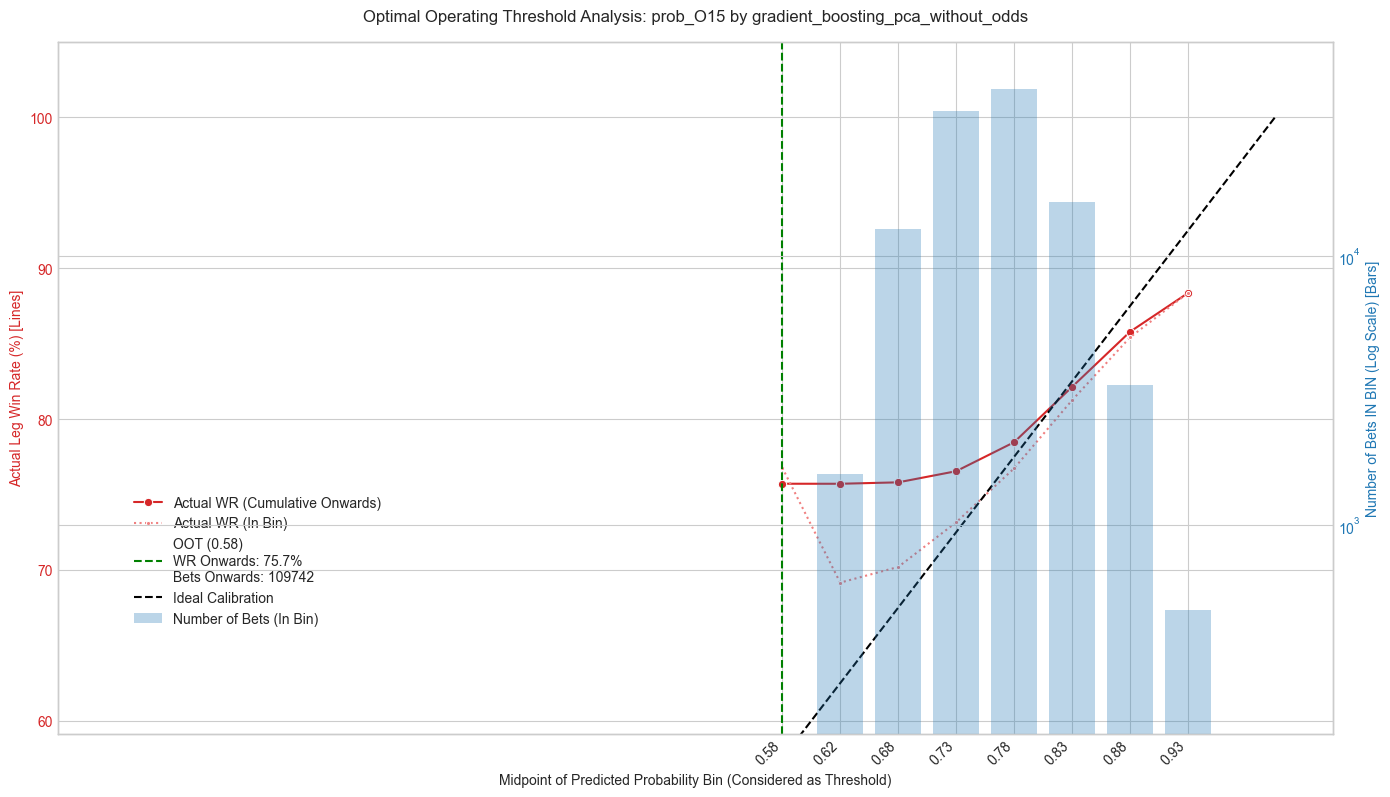

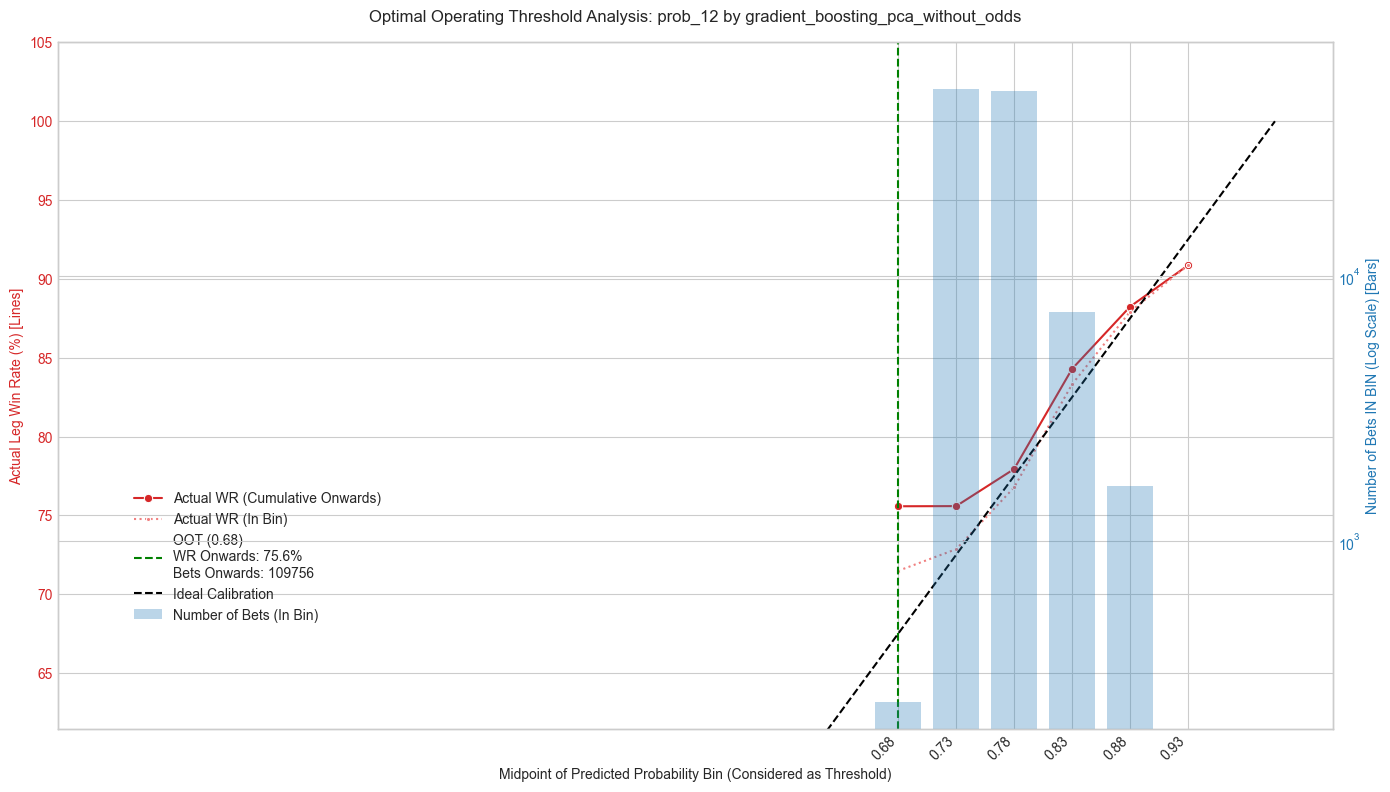

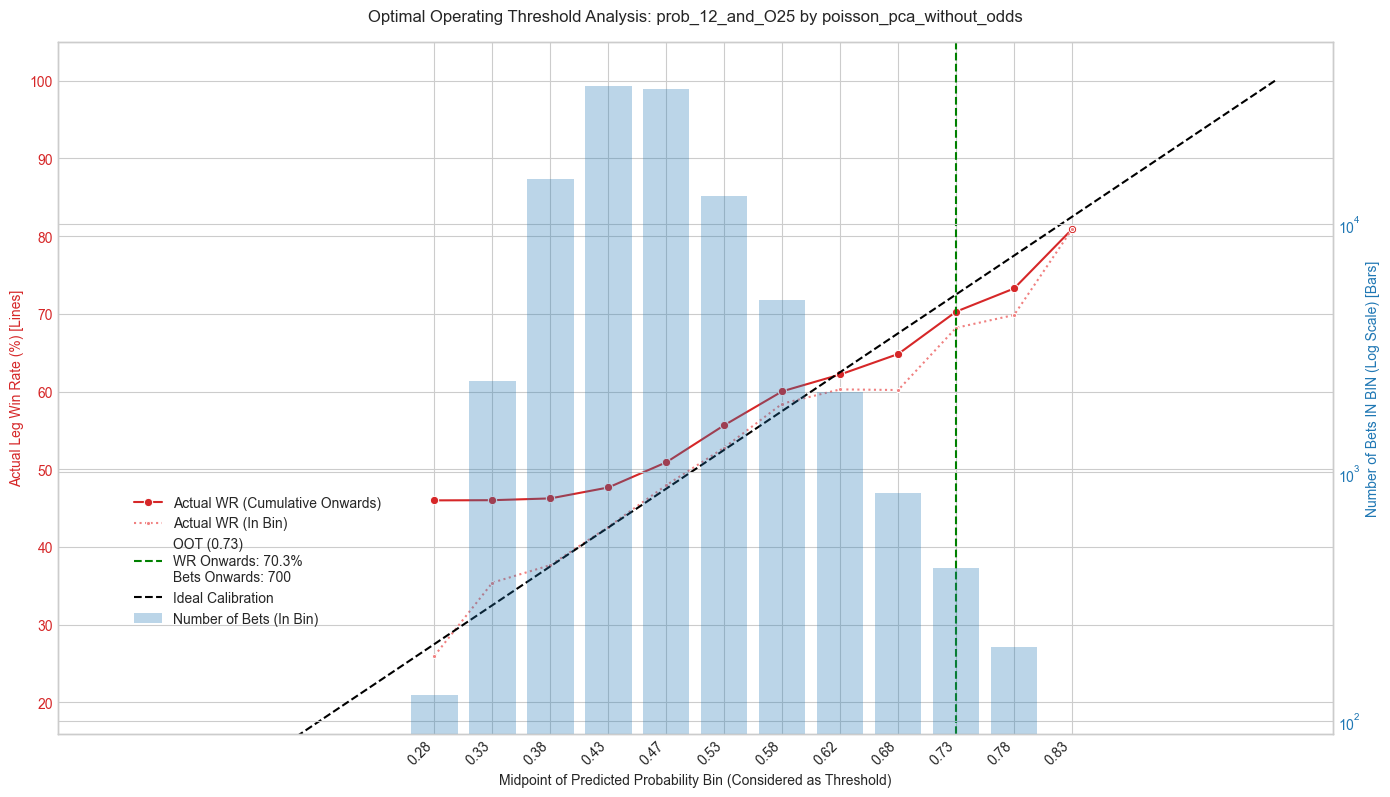

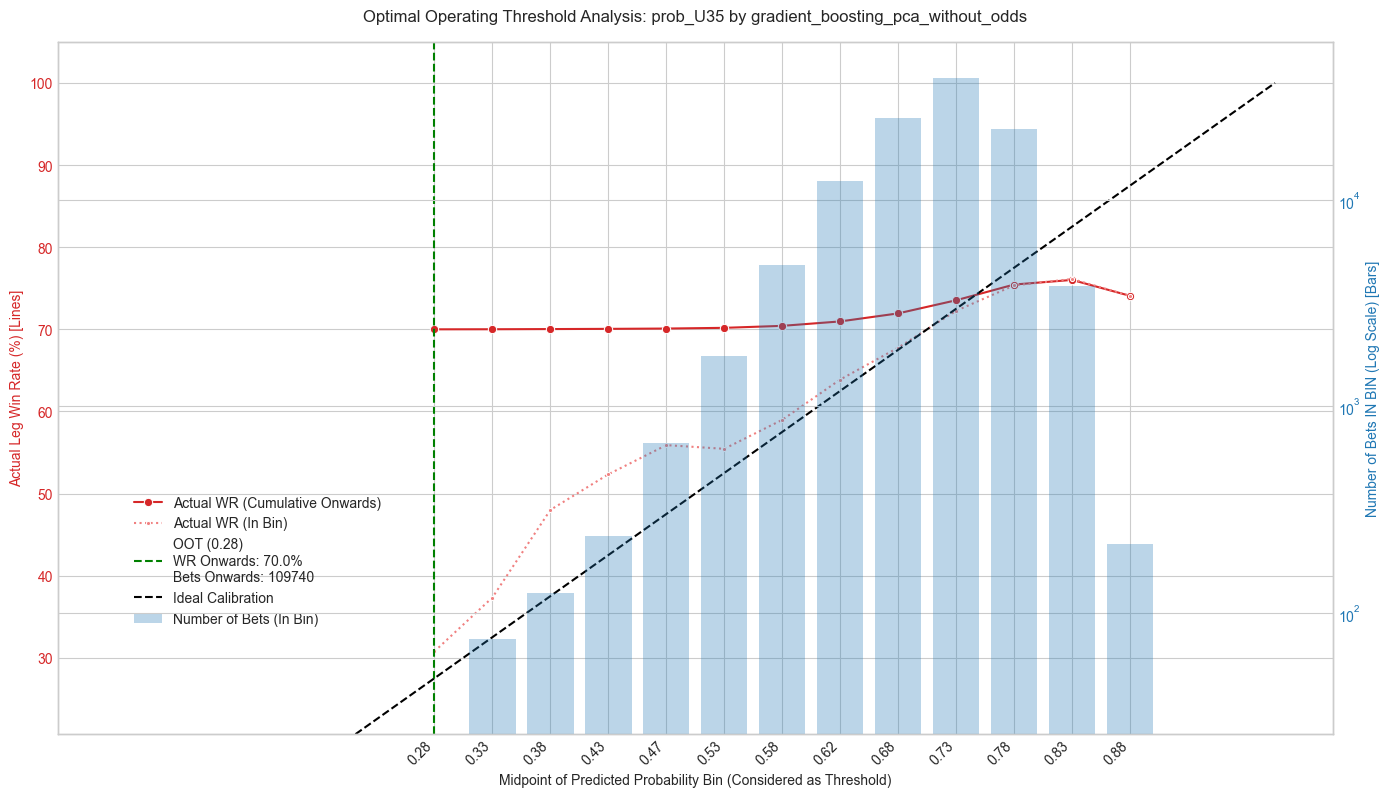

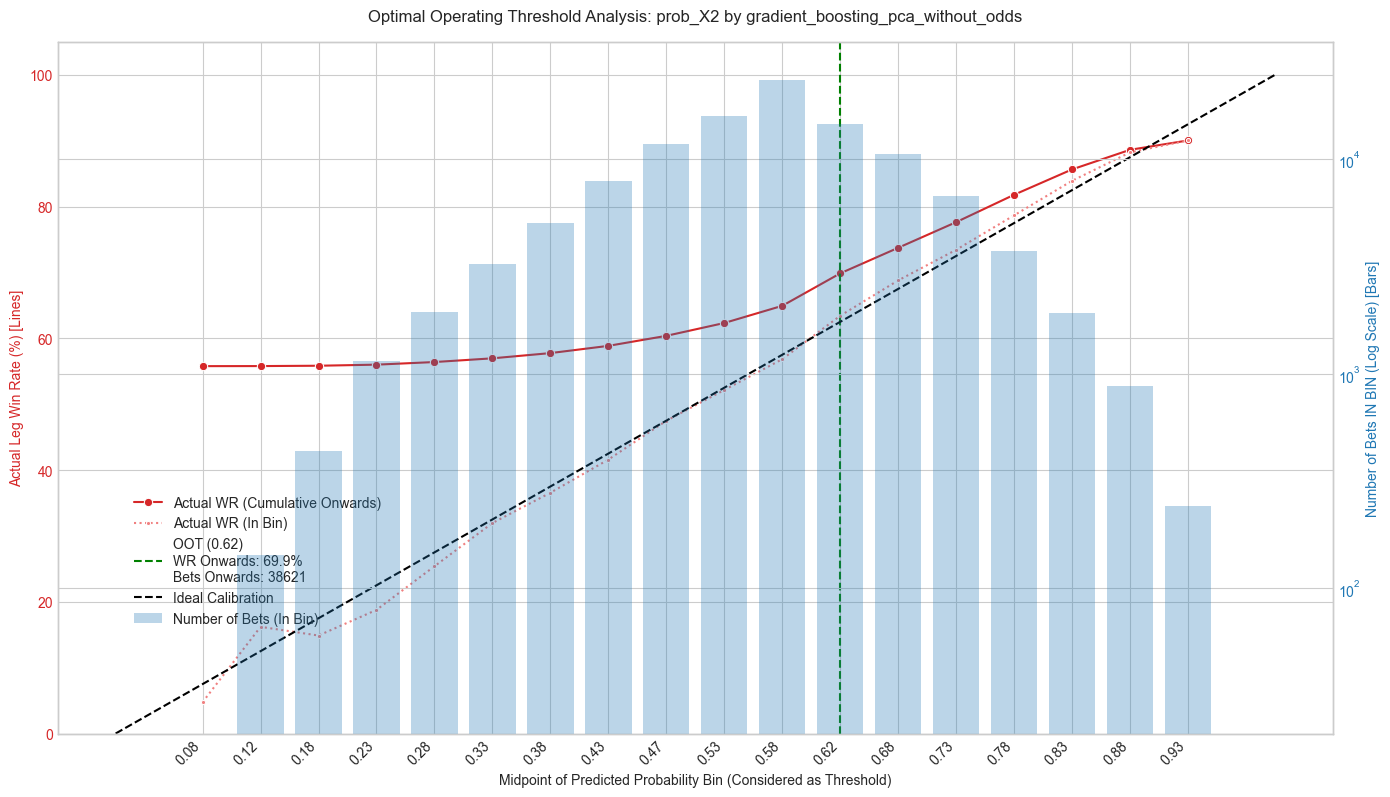

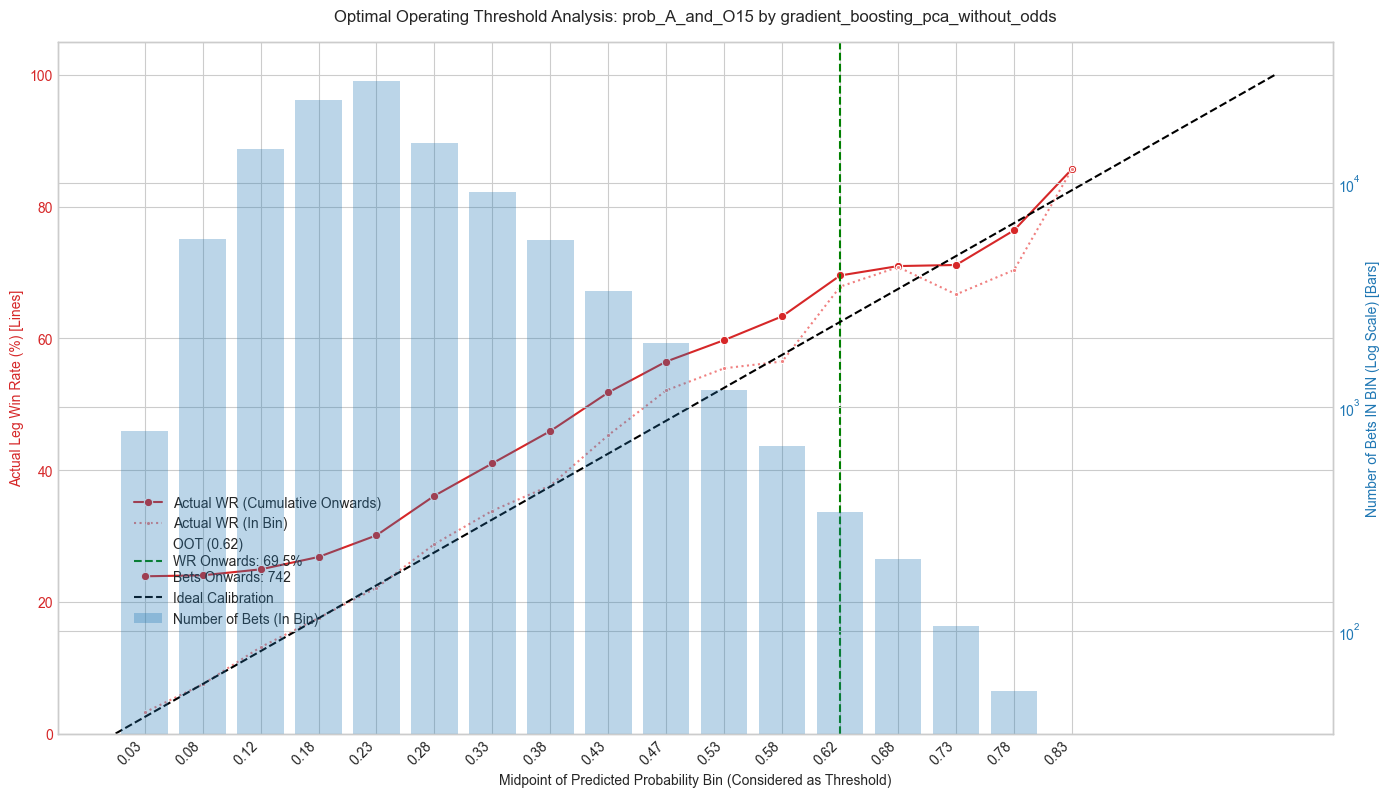

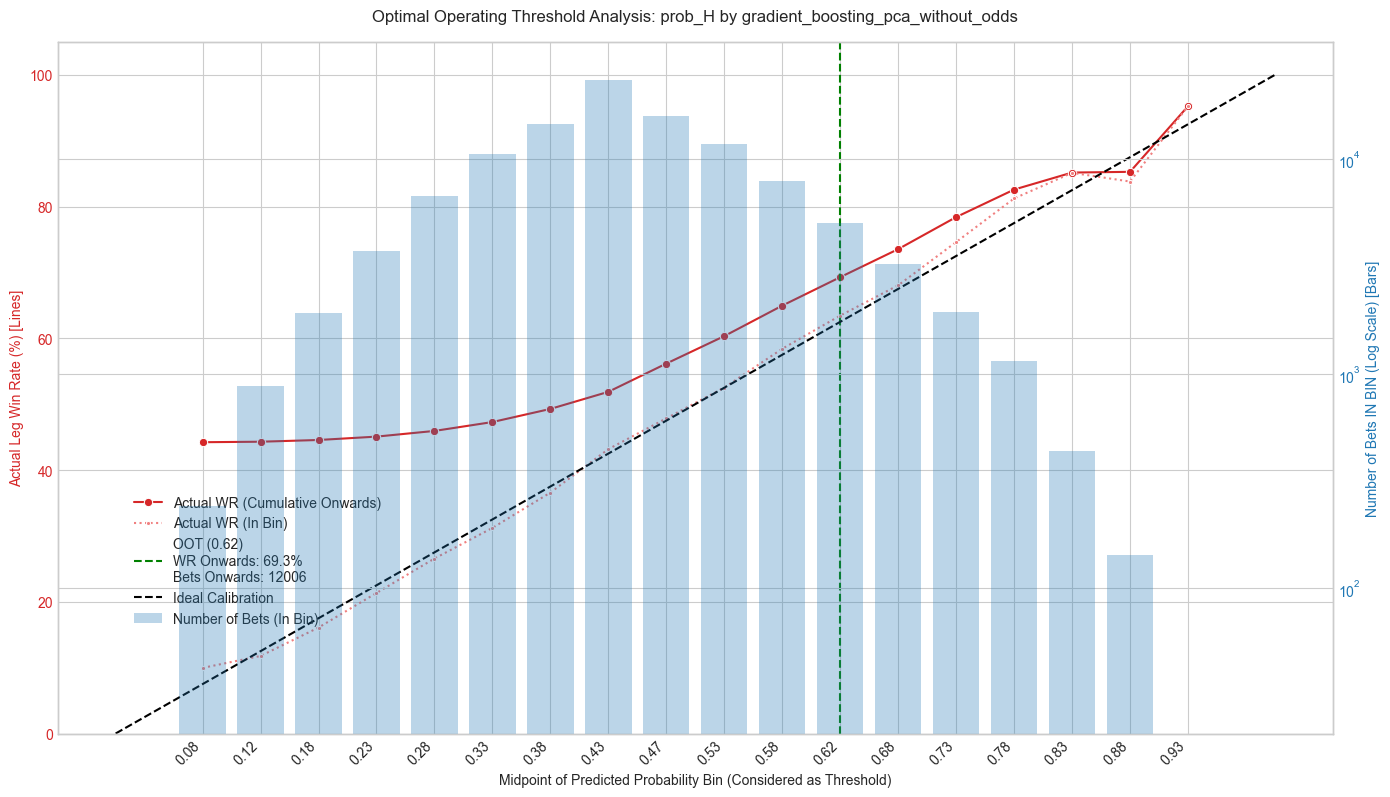

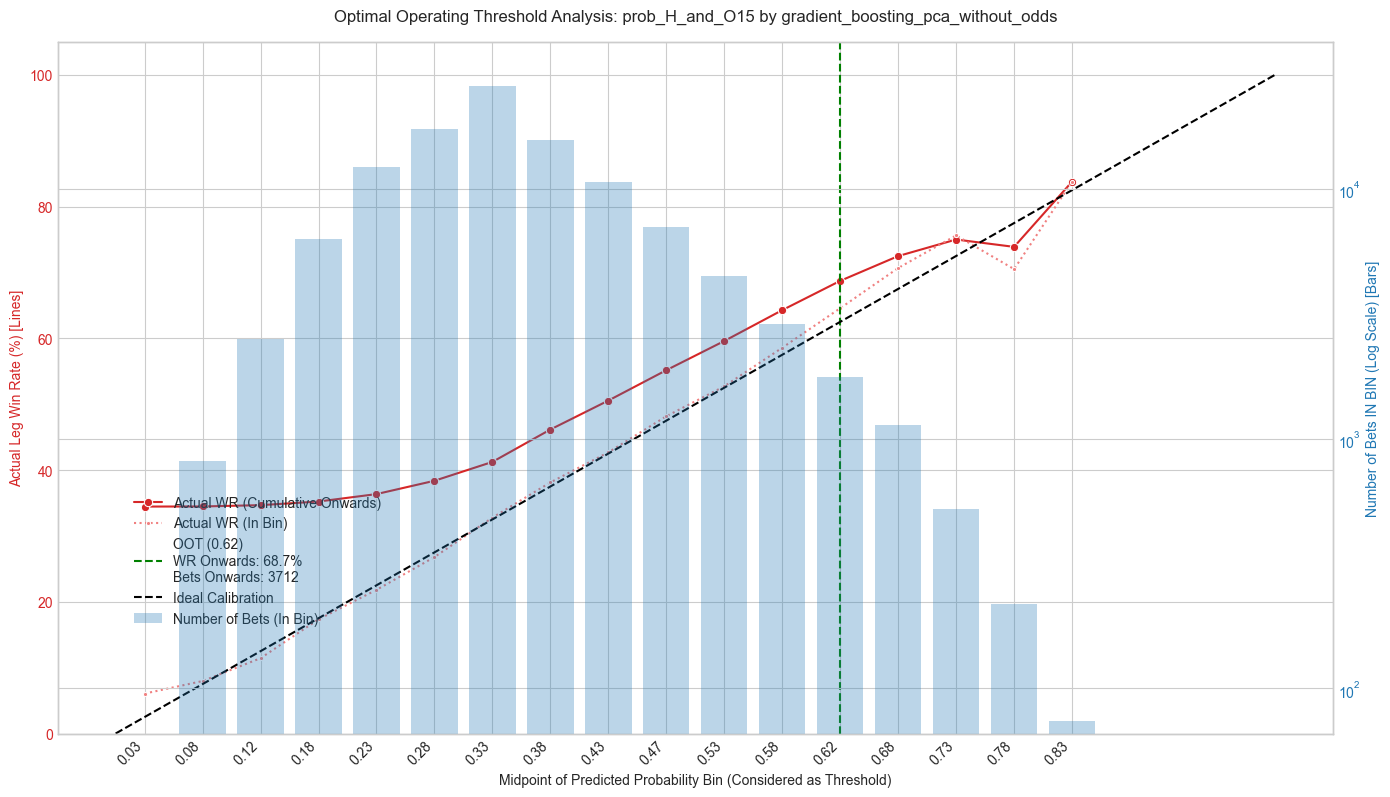

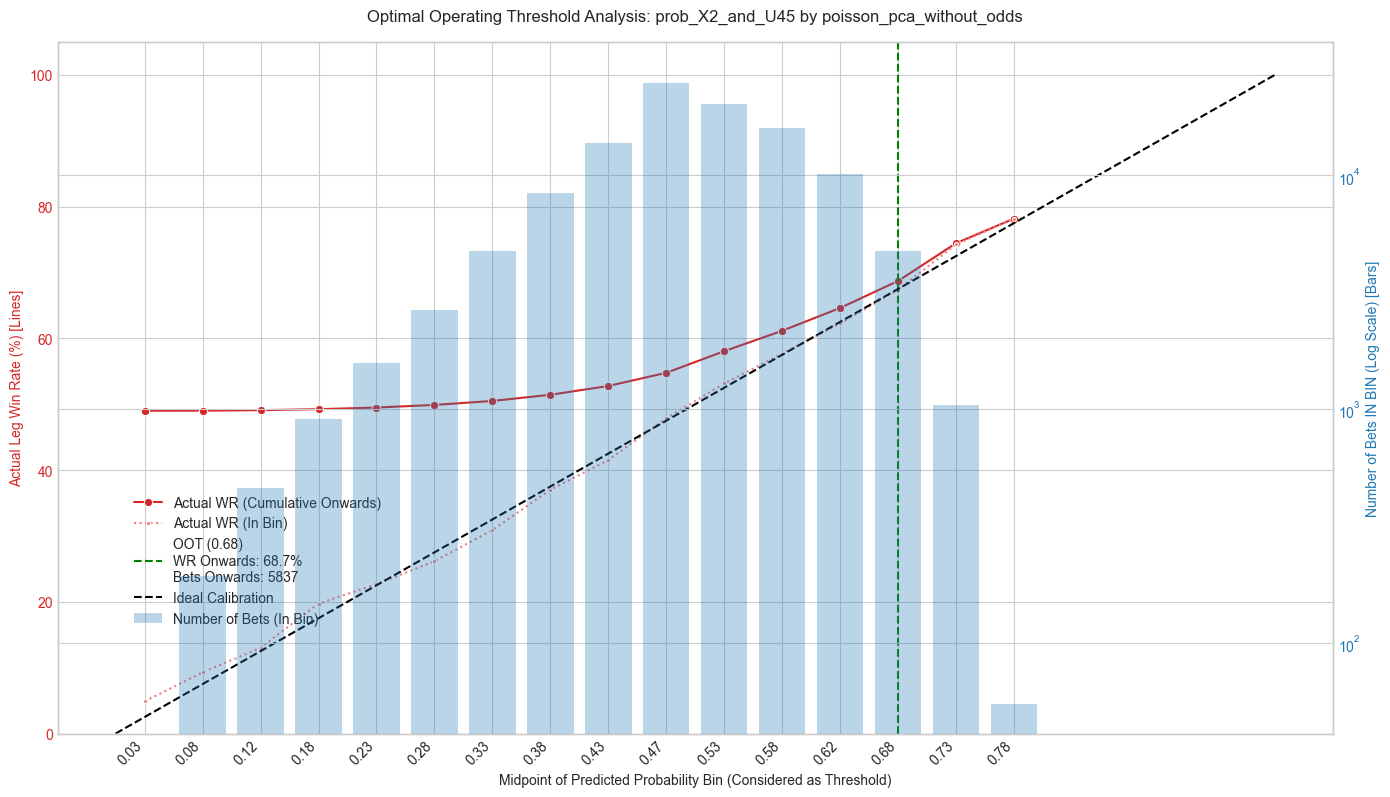

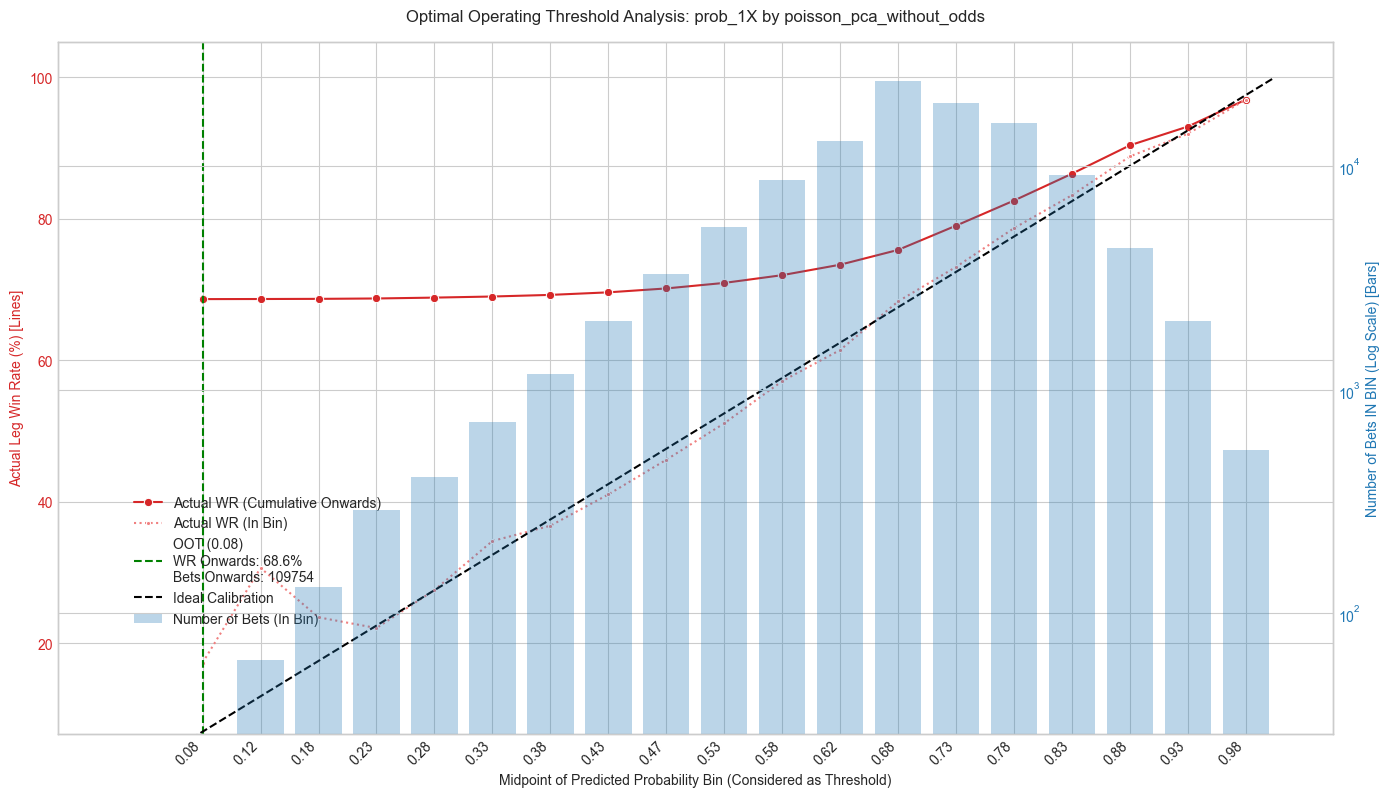

In [15]:
# %% [markdown]
# ## 4.5. Identifying Optimal Operating Thresholds for Market-Model Pairs
#
# Our goal is to find, for each promising market-model pair, the **minimum probability threshold** from which onwards we achieve a consistently high actual win rate while still retaining a reasonable volume of betting opportunities. We're looking for the "sweet spot" before the number of bets diminishes too rapidly for further gains in win rate.

# %%
# --- Ensure master_binned_perf_df exists ---
if 'master_binned_perf_df' not in locals() or master_binned_perf_df.empty:
    print("ERROR: `master_binned_perf_df` not found or is empty. Please run previous analysis cells.")
    # Optionally, load it from CSV if you saved it:
    # master_binned_perf_df = pd.read_csv(NOTEBOOK_OUTPUT_DIR / "master_L0_binned_market_performance.csv")
    # if 'master_binned_perf_df' not in locals() or master_binned_perf_df.empty:
    #     raise ValueError("Failed to load or find master_binned_perf_df. Aborting section.")

# --- Configuration for this Section ---
MIN_BETS_IN_INDIVIDUAL_BIN = 20 # A bin must have at least this many bets to be considered in analysis
MIN_CUMULATIVE_BETS_FOR_THRESHOLD = 100 # We need at least this many bets AT OR ABOVE a chosen threshold
TARGET_MIN_CUMULATIVE_WR = 65.0 # The cumulative win rate from the threshold onwards should be at least this

# %% [markdown]
# ### 4.5.1. Pre-calculating Cumulative Performance Metrics
#
# For each market-model pair, we calculate the cumulative number of bets and the cumulative win rate if we were to bet on all predictions at or above each probability bin's starting point.

# %%
if 'master_binned_perf_df' in locals() and not master_binned_perf_df.empty:
    # Ensure 'prob_bin_mid' is present from previous section (Section 3)
    assert 'prob_bin_mid' in master_binned_perf_df.columns, "'prob_bin_mid' column missing from master_binned_perf_df"

    # Sort by model, market, and then by probability bin (ascending) for cumulative calculations
    binned_data_sorted = master_binned_perf_df.sort_values(
        by=['model', 'market_suffix', 'prob_bin_mid'], ascending=[True, True, True]
    ).copy()

    # Calculate total wins in each bin
    binned_data_sorted['wins_in_bin'] = (binned_data_sorted['num_bets'] * binned_data_sorted['actual_win_rate_pct'] / 100.0).round()

    # Group by model and market, then calculate cumulative sums going from highest prob bin downwards
    # This gives us "performance if betting from this threshold *onwards*"
    binned_data_sorted['cumulative_bets_onwards'] = binned_data_sorted.groupby(
        ['model', 'market_suffix']
    )['num_bets'].transform(lambda x: x[::-1].cumsum()[::-1]) # Cumsum reversed

    binned_data_sorted['cumulative_wins_onwards'] = binned_data_sorted.groupby(
        ['model', 'market_suffix']
    )['wins_in_bin'].transform(lambda x: x[::-1].cumsum()[::-1]) # Cumsum reversed
    
    # Calculate cumulative win rate onwards
    binned_data_sorted['cumulative_wr_onwards'] = np.where(
        binned_data_sorted['cumulative_bets_onwards'] > 0,
        (binned_data_sorted['cumulative_wins_onwards'] / binned_data_sorted['cumulative_bets_onwards']) * 100,
        0 # Or np.nan if preferred for bins with zero cumulative bets onwards
    )
    
    print("Calculated cumulative performance metrics.")
    display(binned_data_sorted[['model', 'market_suffix', 'prob_bin_label', 'num_bets', 'actual_win_rate_pct', 'cumulative_bets_onwards', 'cumulative_wr_onwards']].head())
    binned_data_sorted.to_csv(NOTEBOOK_OUTPUT_DIR / "master_binned_perf_with_cumulative.csv", index=False)
else:
    print("`master_binned_perf_df` not available. Cannot calculate cumulative metrics.")
    binned_data_sorted = pd.DataFrame() # Ensure it exists


# %% [markdown]
# ### 4.5.2. Determining the Optimal Operating Threshold (OOT)
#
# The Optimal Operating Threshold (OOT) is defined as the **lowest predicted probability bin (threshold)** such that:
# 1. The individual bin itself has a sufficient number of samples (`MIN_BETS_IN_INDIVIDUAL_BIN`).
# 2. The cumulative number of bets from this threshold onwards is sufficient (`MIN_CUMULATIVE_BETS_FOR_THRESHOLD`).
# 3. The cumulative win rate from this threshold onwards meets our `TARGET_MIN_CUMULATIVE_WR`.
# 4. Among thresholds satisfying 1-3, we select one that offers a good balance. A simple heuristic might be the one that maximizes `cumulative_wr_onwards`, or a more complex score. For this iteration, we'll look for a "stabilization point" or a point just before a sharp drop in `cumulative_bets_onwards` if WR is stable.
#
# **Heuristic for "Optimal" Threshold:**
# We'll iterate through potential thresholds (probability bins) from lowest to highest probability.
# We are looking for the *first* threshold that:
#   a. Meets the `TARGET_MIN_CUMULATIVE_WR`.
#   b. Has at least `MIN_CUMULATIVE_BETS_FOR_THRESHOLD` bets from that point onwards.
#   c. The bin itself has `MIN_BETS_IN_INDIVIDUAL_BIN`.
# We want the lowest such threshold to maximize opportunities, as long as the WR target is met.

# %%
oot_results = []

if not binned_data_sorted.empty:
    unique_model_market_pairs = binned_data_sorted[['model', 'market_suffix']].drop_duplicates()

    for _, pair_row in unique_model_market_pairs.iterrows():
        model_name = pair_row['model']
        market_name = pair_row['market_suffix']

        pair_data = binned_data_sorted[
            (binned_data_sorted['model'] == model_name) &
            (binned_data_sorted['market_suffix'] == market_name)
        ]

        # Iterate through the bins of this pair, from lower predicted prob to higher
        chosen_oot_row = None
        for _, bin_row in pair_data.iterrows():
            if (bin_row['num_bets'] >= MIN_BETS_IN_INDIVIDUAL_BIN and
                bin_row['cumulative_bets_onwards'] >= MIN_CUMULATIVE_BETS_FOR_THRESHOLD and
                bin_row['cumulative_wr_onwards'] >= TARGET_MIN_CUMULATIVE_WR):
                
                # This bin meets all criteria. It's a candidate.
                # We take the first one we encounter (lowest probability threshold meeting criteria).
                chosen_oot_row = bin_row
                break # Found our OOT for this pair

        if chosen_oot_row is not None:
            oot_results.append({
                'model': model_name,
                'market_suffix': market_name,
                'oot_threshold_prob_mid': chosen_oot_row['prob_bin_mid'],
                'oot_prob_bin_label': chosen_oot_row['prob_bin_label'],
                'wr_in_oot_bin': chosen_oot_row['actual_win_rate_pct'],
                'bets_in_oot_bin': chosen_oot_row['num_bets'],
                'cumulative_wr_at_oot': chosen_oot_row['cumulative_wr_onwards'],
                'cumulative_bets_at_oot': chosen_oot_row['cumulative_bets_onwards']
            })

if oot_results:
    oot_summary_df = pd.DataFrame(oot_results)
    oot_summary_df = oot_summary_df.sort_values(by=['market_suffix', 'cumulative_wr_at_oot'], ascending=[True, False])
    
    print("\n\n--- Optimal Operating Thresholds (OOT) per Market-Model Pair ---")
    display(oot_summary_df)
    oot_summary_df.to_csv(NOTEBOOK_OUTPUT_DIR / "optimal_operating_thresholds.csv", index=False)

    # Now, select the single best model for each market based on this OOT analysis
    idx_best_model_oot_for_market = oot_summary_df.sort_values(
        by=['market_suffix', 'cumulative_wr_at_oot', 'cumulative_bets_at_oot'], # Prioritize WR, then volume
        ascending=[True, False, False]
    ).groupby('market_suffix')['cumulative_wr_at_oot'].idxmax()

    final_oot_selections_df = oot_summary_df.loc[idx_best_model_oot_for_market].sort_values(
        'cumulative_wr_at_oot', ascending=False
    )
    print("\n\n--- FINAL Best Model & Optimal Operating Threshold per Market ---")
    display(final_oot_selections_df)
    final_oot_selections_df.to_csv(NOTEBOOK_OUTPUT_DIR / "final_best_oot_selections.csv", index=False)
    # This `final_oot_selections_df` is what you'd use to build your next elite_config.json
    # The 'oot_threshold_prob_mid' (or the lower bound of 'oot_prob_bin_label') would be your 'min_elite_threshold'.
else:
    print(f"Could not determine Optimal Operating Thresholds for any pair meeting criteria (Target WR: {TARGET_MIN_CUMULATIVE_WR}%, Min Cum. Bets: {MIN_CUMULATIVE_BETS_FOR_THRESHOLD})")
    final_oot_selections_df = pd.DataFrame() # Ensure it exists

# %% [markdown]
# ### 4.5.3. Visualizing Performance at the Optimal Operating Threshold
#
# This plot will be similar to your example, showing the full spectrum for a given market-model, but highlighting the OOT we identified.

# %%
if 'final_oot_selections_df' in locals() and not final_oot_selections_df.empty and \
   'binned_data_sorted' in locals() and not binned_data_sorted.empty:

    num_markets_to_visualize_oot = min(10, len(final_oot_selections_df))
    markets_to_visualize_oot_df = final_oot_selections_df.head(num_markets_to_visualize_oot)

    print(f"\n--- Detailed OOT Performance Plots for Top {num_markets_to_visualize_oot} Selections ---")

    for _, row_oot_selection in markets_to_visualize_oot_df.iterrows():
        market_to_plot = row_oot_selection['market_suffix']
        model_to_plot = row_oot_selection['model']
        identified_oot_val = row_oot_selection['oot_threshold_prob_mid']
        oot_wr_onwards = row_oot_selection['cumulative_wr_at_oot']
        oot_bets_onwards = int(row_oot_selection['cumulative_bets_at_oot'])

        # Get all binned data for this specific market-model pair from the full binned table
        specific_pair_full_binned_data = binned_data_sorted[
            (binned_data_sorted['model'] == model_to_plot) &
            (binned_data_sorted['market_suffix'] == market_to_plot)
        ].sort_values(by='prob_bin_mid').copy()

        if specific_pair_full_binned_data.empty: continue
            
        fig, ax1 = plt.subplots(figsize=(14, 8))

        # Plot Cumulative Win Rate from each bin ONWARDS (Primary Y-axis, Red Line)
        color1 = 'tab:red'
        ax1.set_xlabel('Midpoint of Predicted Probability Bin (Considered as Threshold)')
        ax1.set_ylabel('Actual Leg Win Rate (%) [Lines]', color=color1)
        sns.lineplot(x='prob_bin_mid', y='cumulative_wr_onwards', data=specific_pair_full_binned_data, 
                     ax=ax1, color=color1, marker='o', label='Actual WR (Cumulative Onwards)')
        # Also plot the win rate IN EACH BIN
        sns.lineplot(x='prob_bin_mid', y='actual_win_rate_pct', data=specific_pair_full_binned_data,
                     ax=ax1, color='lightcoral', marker='.', linestyle=':', label='Actual WR (In Bin)')
        
        ax1.tick_params(axis='y', labelcolor=color1)
        ax1.set_ylim(max(0, specific_pair_full_binned_data['actual_win_rate_pct'].min() - 10 if specific_pair_full_binned_data['actual_win_rate_pct'].min() is not np.nan else 0), 105)
        
        # Highlight the chosen Optimal Operating Threshold (OOT)
        ax1.axvline(x=identified_oot_val, color='green', linestyle='--', 
                    label=f'OOT ({identified_oot_val:.2f})\nWR Onwards: {oot_wr_onwards:.1f}%\nBets Onwards: {oot_bets_onwards}')

        # Add ideal calibration line
        ax1.plot([0, 1], [0, 100], color='black', linestyle='--', label='Ideal Calibration')
        
        # Plot Number of Bets IN EACH BIN (Secondary Y-axis, Blue Bars)
        ax2 = ax1.twinx()
        color2 = 'tab:blue'
        ax2.set_ylabel('Number of Bets IN BIN (Log Scale) [Bars]', color=color2)
        ax2.bar(specific_pair_full_binned_data['prob_bin_mid'], specific_pair_full_binned_data['num_bets'], 
                color=color2, alpha=0.3, width=0.04, label='Number of Bets (In Bin)') # Width adjusted for 0.05 bins
        ax2.tick_params(axis='y', labelcolor=color2)
        ax2.set_yscale('log')
        min_y_ax2_val = specific_pair_full_binned_data[specific_pair_full_binned_data['num_bets'] > 0]['num_bets'].min()
        min_y_ax2 = max(1, min_y_ax2_val if pd.notna(min_y_ax2_val) else 1)
        max_y_ax2_val = specific_pair_full_binned_data['num_bets'].max()
        max_y_ax2 = max(10, max_y_ax2_val if pd.notna(max_y_ax2_val) else 10)
        ax2.set_ylim(min_y_ax2, max_y_ax2 * 1.5) # Adjust multiplier as needed for visibility

        fig.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust rect for title
        plt.title(f'Optimal Operating Threshold Analysis: {market_to_plot} by {model_to_plot}', pad=15)
        
        # Combine legends
        lines_leg, labels_leg = ax1.get_legend_handles_labels()
        bars_leg, bar_labels_leg = ax2.get_legend_handles_labels()
        # Place legend strategically, e.g., lower right or best, might need adjustment
        ax1.legend(lines_leg + bars_leg, labels_leg + bar_labels_leg, loc='center left', bbox_to_anchor=(0.05, 0.25))
        
        unique_bin_mids = sorted(specific_pair_full_binned_data['prob_bin_mid'].unique())
        ax1.set_xticks(unique_bin_mids)
        ax1.set_xticklabels([f"{mid:.2f}" for mid in unique_bin_mids], rotation=45, ha="right")
        
        plt.savefig(NOTEBOOK_OUTPUT_DIR / f"oot_plot_{model_to_plot}_{market_to_plot.replace('prob_','')}.png")
        plt.show()
        plt.close()
else:
    print("DataFrames for plotting OOT performance not available.")


--- Summary of Performance at Optimal Operating Thresholds (OOTs) ---


,Market,Best Model,Min. Pred. Prob (OOT),OOT Bin Label,Bets From OOT Onwards,WR From OOT Onwards (%),WR In OOT Bin (%),Bets In OOT Bin
13,prob_O15,gradient_boosting_pca_without_odds,0.58,[0.55-0.60),109742,75.72,76.79,168
0,prob_12,gradient_boosting_pca_without_odds,0.68,[0.65-0.70),109756,75.58,71.49,249
29,prob_12_and_O25,poisson_pca_without_odds,0.73,[0.70-0.75),700,70.29,68.20,412
15,prob_U35,gradient_boosting_pca_without_odds,0.28,[0.25-0.30),109740,70.00,30.77,26
16,prob_X2,gradient_boosting_pca_without_odds,0.62,[0.60-0.65),38621,69.86,63.42,14526
8,prob_A_and_O15,gradient_boosting_pca_without_odds,0.62,[0.60-0.65),742,69.54,67.85,339
10,prob_H,gradient_boosting_pca_without_odds,0.62,[0.60-0.65),12006,69.28,63.45,5064
11,prob_H_and_O15,gradient_boosting_pca_without_odds,0.62,[0.60-0.65),3712,68.72,64.57,1764
45,prob_X2_and_U45,poisson_pca_without_odds,0.68,[0.65-0.70),5837,68.72,67.40,4745
30,prob_1X,poisson_pca_without_odds,0.08,[0.05-0.10),109754,68.65,17.24,29


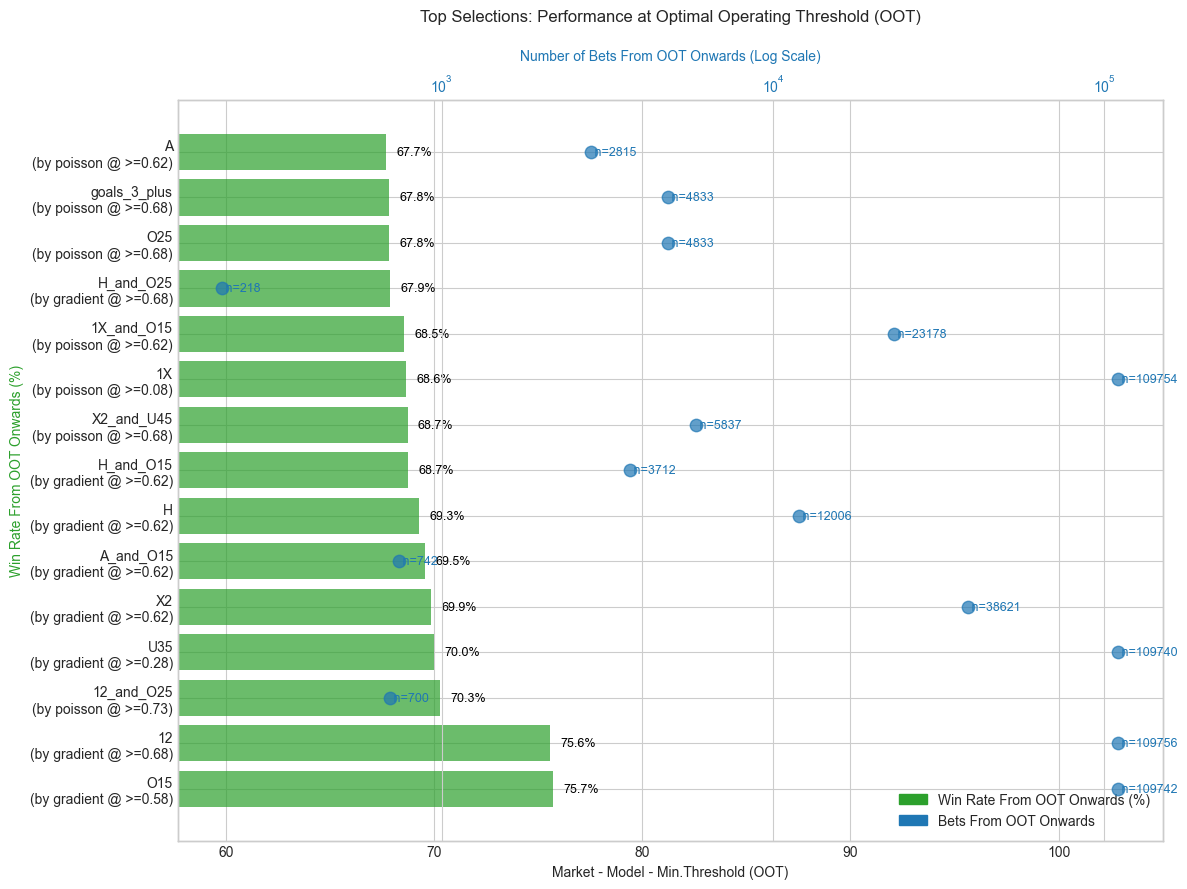

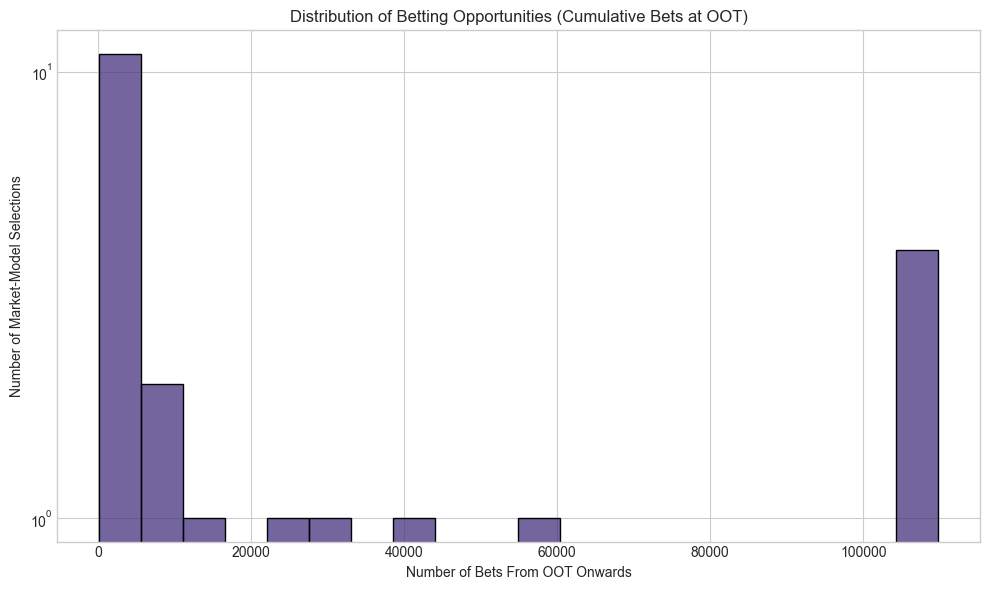


Descriptive Statistics for 'Bets From OOT Onwards':
count       22.00
mean     28719.64
std      41655.33
min        123.00
10%        234.40
25%        821.00
50%       5335.00
75%      37015.00
90%     109741.80
max     109756.00
Name: Bets From OOT Onwards, dtype: float64


In [16]:
# %% [markdown]
# ## 4.6. Performance Summary at Optimal Operating Thresholds (OOTs)
#
# This section summarizes the performance characteristics of our best market-model pairs when applying the identified Optimal Operating Threshold (OOT). We focus on understanding the number of betting opportunities and the achieved win rate from these specific thresholds onwards.

# %%
# --- Ensure final_oot_selections_df exists ---
if 'final_oot_selections_df' not in locals() or final_oot_selections_df.empty:
    print("ERROR: `final_oot_selections_df` not found or is empty. Please run previous analysis cells (Section 4.5.2).")
    # Optionally, try to load it if saved:
    # final_oot_selections_df = pd.read_csv(NOTEBOOK_OUTPUT_DIR / "final_best_oot_selections.csv")
    # if 'final_oot_selections_df' not in locals() or final_oot_selections_df.empty:
    #     raise ValueError("Failed to load or find final_oot_selections_df. Aborting section.")

# For display and consistency
pd.set_option('display.float_format', '{:.2f}'.format)

# %% [markdown]
# ### 4.6.1. Tabular Summary of OOT Performance
#
# A clean table showing each top market-model, its OOT, the number of bets from that threshold onwards, and the cumulative win rate achieved.

# %%
if 'final_oot_selections_df' in locals() and not final_oot_selections_df.empty:
    oot_summary_table = final_oot_selections_df[[
        'market_suffix',
        'model',
        'oot_threshold_prob_mid', # The effective minimum probability threshold
        'oot_prob_bin_label',     # The specific bin label for the OOT
        'cumulative_bets_at_oot', # Total bets AT or ABOVE this threshold
        'cumulative_wr_at_oot',   # Win rate for those cumulative bets
        'wr_in_oot_bin',          # Win rate just in the threshold's specific bin (for context)
        'bets_in_oot_bin'         # Bets just in the threshold's specific bin (for context)
    ]].copy()

    oot_summary_table.rename(columns={
        'market_suffix': 'Market',
        'model': 'Best Model',
        'oot_threshold_prob_mid': 'Min. Pred. Prob (OOT)',
        'oot_prob_bin_label': 'OOT Bin Label',
        'cumulative_bets_at_oot': 'Bets From OOT Onwards',
        'cumulative_wr_at_oot': 'WR From OOT Onwards (%)',
        'wr_in_oot_bin': 'WR In OOT Bin (%)',
        'bets_in_oot_bin': 'Bets In OOT Bin'
    }, inplace=True)

    oot_summary_table = oot_summary_table.sort_values(by='WR From OOT Onwards (%)', ascending=False)

    print("\n--- Summary of Performance at Optimal Operating Thresholds (OOTs) ---")
    from IPython.display import display
    display(oot_summary_table)
    oot_summary_table.to_csv(NOTEBOOK_OUTPUT_DIR / "oot_performance_summary.csv", index=False)
else:
    print("`final_oot_selections_df` not available for tabular summary.")

# %% [markdown]
# ### 4.6.2. Visualizing Bets Onwards vs. Win Rate Onwards
#
# This plot helps visualize the trade-off for our chosen OOTs: how many betting opportunities do we get (volume) vs. the achieved win rate.

# %%
if 'oot_summary_table' in locals() and not oot_summary_table.empty:
    # For better visualization, let's create a combined label for the y-axis
    oot_summary_table['selection_label'] = oot_summary_table['Market'].str.replace('prob_', '') + \
                                           "\n(by " + oot_summary_table['Best Model'].apply(lambda x: x.split('_')[0]) + \
                                           f" @ >=" + oot_summary_table['Min. Pred. Prob (OOT)'].round(2).astype(str) + ")"

    # Sort by Win Rate for plotting
    plot_data_oot_summary = oot_summary_table.sort_values('WR From OOT Onwards (%)', ascending=False).head(15) # Top 15

    fig, ax1 = plt.subplots(figsize=(12, 10))

    # Plot Win Rate Onwards (Primary Y-axis - Left)
    color1 = 'tab:green'
    ax1.set_xlabel('Market - Model - Min.Threshold (OOT)')
    ax1.set_ylabel('Win Rate From OOT Onwards (%)', color=color1)
    
    # Create barplot manually to avoid seaborn issues with palette
    bars = ax1.barh(y=np.arange(len(plot_data_oot_summary)), 
                   width=plot_data_oot_summary['WR From OOT Onwards (%)'],
                   color=color1, alpha=0.7)
    
    # Set y-tick labels to our custom selection labels
    ax1.set_yticks(np.arange(len(plot_data_oot_summary)))
    ax1.set_yticklabels(plot_data_oot_summary['selection_label'])
    
    ax1.tick_params(axis='y')
    ax1.set_xlim(max(0, plot_data_oot_summary['WR From OOT Onwards (%)'].min() - 10 if not plot_data_oot_summary.empty else 0), 105)
    
    # Add text annotations for WR
    for i, bar in enumerate(bars):
        wr_value = plot_data_oot_summary.iloc[i]['WR From OOT Onwards (%)']
        ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{wr_value:.1f}%",
                 ha="left", va="center", color='black', fontsize=9)

    # Plot Bets Onwards (Secondary Y-axis - Right)
    ax2 = ax1.twiny() # Share y-axis, different x-axis on top
    color2 = 'tab:blue'
    ax2.set_xlabel('Number of Bets From OOT Onwards (Log Scale)', color=color2, labelpad=10)
    
    # Use a scatter/strip plot for bets on the secondary x-axis
    # To align with bars, we need to plot against the categorical y-axis positions
    y_positions = np.arange(len(plot_data_oot_summary))
    ax2.scatter(plot_data_oot_summary['Bets From OOT Onwards'], y_positions, 
                color=color2, marker='o', s=80, alpha=0.7, label='Bets From OOT Onwards')
    ax2.tick_params(axis='x', labelcolor=color2)
    ax2.set_xscale('log')
    
    # Add text annotations for Bets
    for i, (_, row) in enumerate(plot_data_oot_summary.iterrows()):
        ax2.text(row['Bets From OOT Onwards'], i, 
                 f" n={int(row['Bets From OOT Onwards'])}",
                 color=color2, ha="left", va="center", fontsize=9)

    plt.title('Top Selections: Performance at Optimal Operating Threshold (OOT)', pad=20)
    fig.tight_layout(rect=[0, 0.05, 1, 0.95]) # Adjust layout to prevent overlap
    
    # Create a single legend
    import matplotlib.patches as mpatches
    bar_patch = mpatches.Patch(color=color1, label='Win Rate From OOT Onwards (%)')
    scatter_patch = mpatches.Patch(color=color2, label='Bets From OOT Onwards')
    
    ax1.legend(handles=[bar_patch, scatter_patch], loc='lower right')

    plt.savefig(NOTEBOOK_OUTPUT_DIR / "oot_summary_bets_vs_winrate.png")
    plt.show()
    plt.close()

else:
    print("OOT summary table not available for plotting.")


# %% [markdown]
# ### 4.6.3. Distribution of Opportunities (Number of Bets from OOT Onwards)
#
# Understanding how many selections provide a high volume of bets vs. those that are more niche.

# %%
if 'oot_summary_table' in locals() and not oot_summary_table.empty:
    plt.figure(figsize=(10, 6))
    sns.histplot(oot_summary_table['Bets From OOT Onwards'], bins=20, kde=False)
    plt.title('Distribution of Betting Opportunities (Cumulative Bets at OOT)')
    plt.xlabel('Number of Bets From OOT Onwards')
    plt.ylabel('Number of Market-Model Selections')
    plt.yscale('log') # Often useful if many selections have few bets
    plt.tight_layout()
    plt.savefig(NOTEBOOK_OUTPUT_DIR / "oot_bets_onwards_distribution.png")
    plt.show()
    plt.close()

    print("\nDescriptive Statistics for 'Bets From OOT Onwards':")
    print(oot_summary_table['Bets From OOT Onwards'].describe(percentiles=[.1, .25, .5, .75, .9]))
else:
    print("OOT summary table not available for distribution plot.")

# %% [markdown]
# ### 4.6.4. Further Insights & Next Steps based on OOT Analysis:
#
# *   **Review `oot_performance_summary.csv` and `final_best_oot_selections.csv`:** These are your key references for building the next `elite_config.json`.
# *   **High WR, High Volume:** Selections at the top of `final_best_oot_selections.csv` (sorted by `cumulative_wr_at_oot` then `cumulative_bets_at_oot`) are your prime candidates.
# *   **High WR, Low Volume:** Some selections might have excellent win rates but very few cumulative bets. These are still valuable but might be used more sparingly or require models to become "more confident" more often. This points to model improvement areas – how can the model generate these high-probability predictions more frequently without losing accuracy?
# *   **Moderate WR, High Volume:** These are your workhorse selections if the WR is still acceptable.
# *   **Next `elite_config.json`:** Use the `Market`, `Best Model`, and `Min. Pred. Prob (OOT)` (which is `oot_threshold_prob_mid`) from `final_best_oot_selections.csv` to build your next set of rules for `improved_parlay.py`.
# *   **Focus Model Refinement:** For selections where the OOT still doesn't yield your desired win rate, or where the number of bets is too low, those market-model pairs become targets for the next round of model fine-tuning (feature engineering, hyperparameter optimization focused on calibration in higher probability regions, etc.).

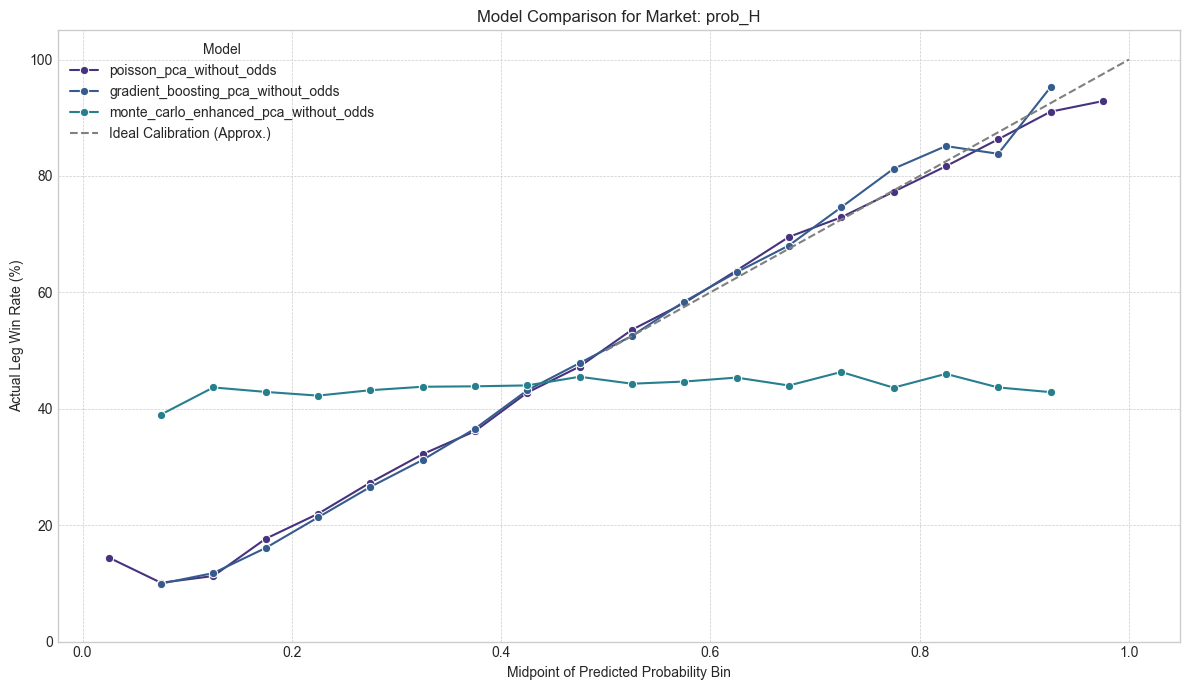

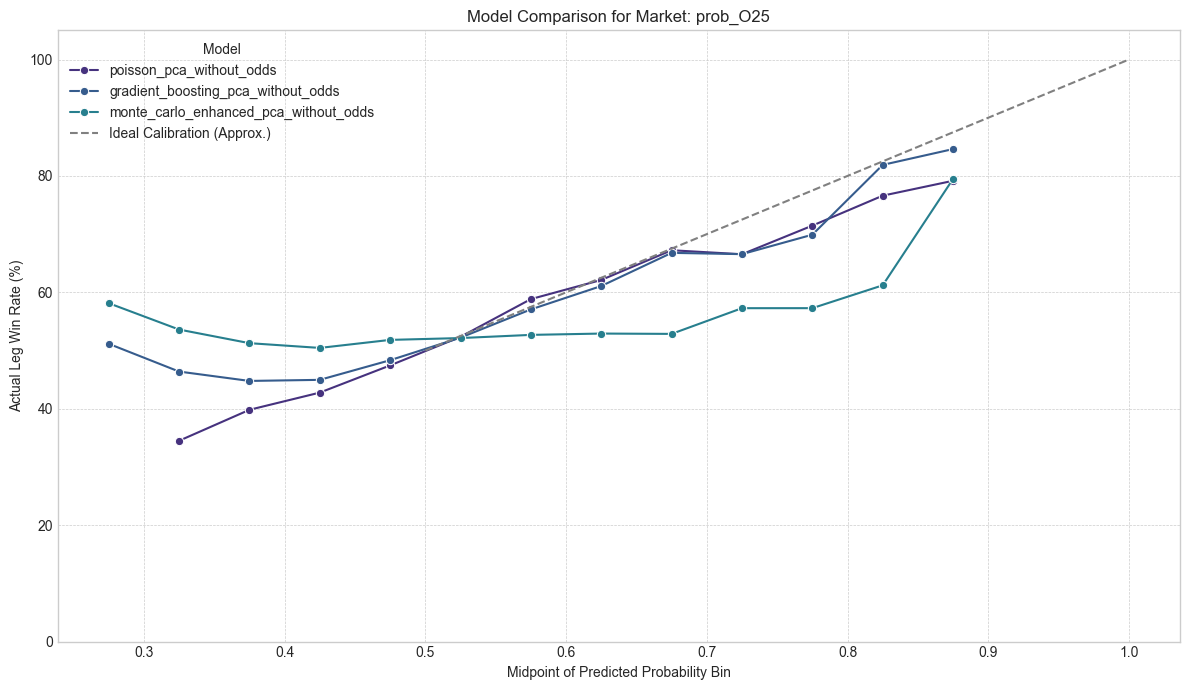

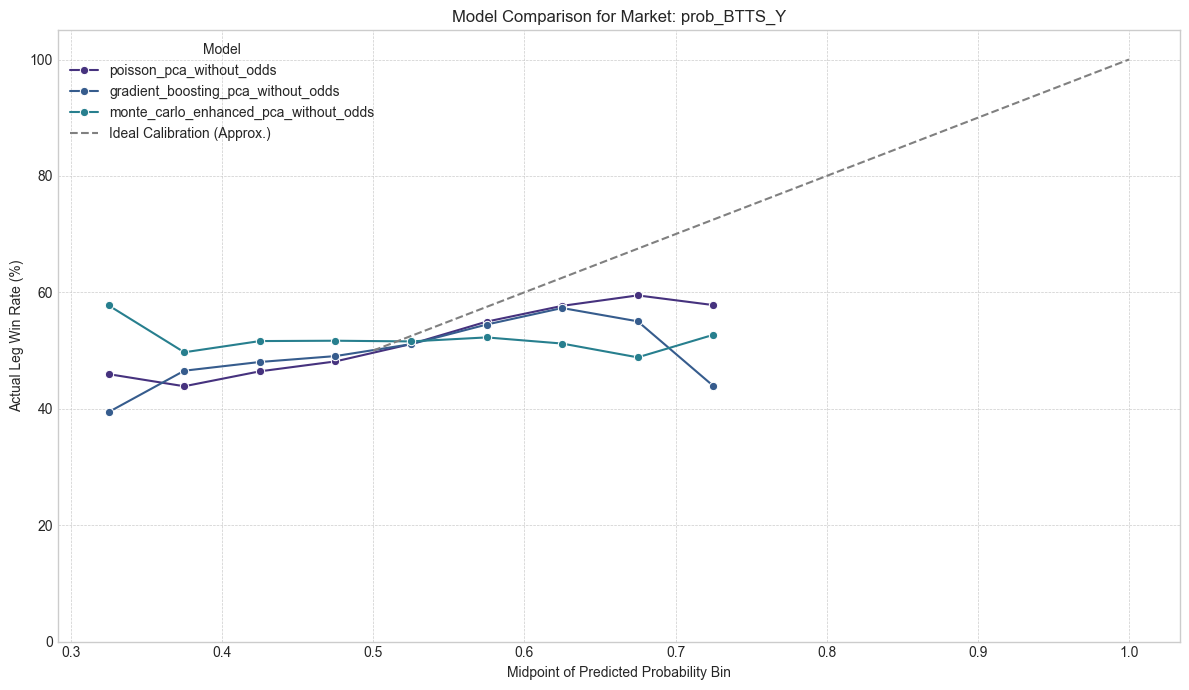

Market prob_U45 not found in binned performance data for comparison.


In [17]:
# %% [markdown]
# ## 5. Cross-Model Comparison for Key Markets
#
# For a few important markets, let's directly compare how each model performs across different probability thresholds.

# %%
if not master_binned_perf_df.empty:
    KEY_MARKETS_TO_COMPARE = ['prob_H', 'prob_O25', 'prob_BTTS_Y', 'prob_U45'] # Example, choose your key markets

    for market_comp_suffix in KEY_MARKETS_TO_COMPARE:
        if market_comp_suffix not in master_binned_perf_df['market_suffix'].unique():
            print(f"Market {market_comp_suffix} not found in binned performance data for comparison.")
            continue

        market_data_for_comparison = master_binned_perf_df[
            (master_binned_perf_df['market_suffix'] == market_comp_suffix) &
            (master_binned_perf_df['num_bets'] >= MIN_SAMPLES_FOR_BIN) # Only bins with enough samples
        ]
        
        if market_data_for_comparison.empty:
            print(f"No sufficient data for market {market_comp_suffix} across models for comparison plot.")
            continue

        plt.figure(figsize=(12, 7))
        sns.lineplot(x='prob_bin_mid', y='actual_win_rate_pct', hue='model', 
                     data=market_data_for_comparison, marker='o', errorbar=None) # errorbar=None if no std dev calculated
        plt.plot([0.5, 1.0], [50, 100], linestyle='--', color='grey', label='Ideal Calibration (Approx.)') # Reference
        plt.title(f'Model Comparison for Market: {market_comp_suffix}')
        plt.xlabel('Midpoint of Predicted Probability Bin')
        plt.ylabel('Actual Leg Win Rate (%)')
        plt.legend(title='Model')
        plt.ylim(0, 105)
        plt.grid(True, which='both', linestyle='--', linewidth=0.5)
        plt.tight_layout()
        plt.savefig(NOTEBOOK_OUTPUT_DIR / f"model_comparison_{market_comp_suffix.replace('prob_','')}.png")
        plt.show()
        plt.close()
else:
    print("Master binned performance DataFrame is empty. Skipping Section 5.")

In [18]:
# %% [markdown]
# ### X.A. Define & Isolate Segments for a Chosen Market-Model Pair
#
# We will pick one top-performing market-model pair from `final_oot_selections_df` and define our analysis segments.
# This DataFrame (`final_oot_selections_df`) should have been generated in Section 4.5.2 and contains the
# best model and its Optimal Operating Threshold (OOT) for each market.

# %%
# Ensure DataFrames are available from previous notebook cells or loaded correctly
if 'final_oot_selections_df' not in locals() or final_oot_selections_df.empty:
    # Attempt to load if not found in locals, assuming it was saved
    path_to_oot_csv = NOTEBOOK_OUTPUT_DIR / "final_best_oot_selections.csv"
    if path_to_oot_csv.exists():
        print(f"Attempting to load `final_oot_selections_df` from {path_to_oot_csv}")
        final_oot_selections_df = pd.read_csv(path_to_oot_csv)
        if final_oot_selections_df.empty:
            raise ValueError(f"`final_oot_selections_df` loaded from CSV is empty. Please check {path_to_oot_csv} or re-run Section 4.5.2.")
    else:
        raise ValueError("`final_oot_selections_df` is not defined or empty and could not be loaded from CSV. Please run Section 4.5.2 first.")

if 'oof_df_with_actuals' not in locals() or oof_df_with_actuals.empty:
    # Attempt to load if not found (assuming it includes derived actuals)
    # This part is more complex as 'oof_df_with_actuals' is usually an in-memory transformation.
    # For simplicity here, we'll assume it should be present from earlier cells.
    # If not, you'd need to re-run the OOF loading and actual outcome derivation from Section 1.
    raise ValueError("`oof_df_with_actuals` is not defined or empty. Please run Section 1 of the notebook first.")

# --- Get Feature Lists from your BaseFeatureConfig ---
try:
    # Correct the sys.path if your notebook is not in the AgenticFC888 root
    # If your notebook is in AgenticFC888/notebooks/
    # And features.py is in AgenticFC888/models/utils/
    # Then you might need to add AgenticFC888 to sys.path if not already done globally
    import sys
    from pathlib import Path
    PROJECT_ROOT_NB = Path("/Users/barroca888/Downloads/Agenticfc/AgenticFC888") # Define your project root
    if str(PROJECT_ROOT_NB) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT_NB))
        print(f"Added {PROJECT_ROOT_NB} to sys.path for module imports.")

    from models.utils.features import get_feature_config # This should now work
    
    # You are analyzing 'without_odds' data for this L0 OOF
    feature_cfg_for_analysis = get_feature_config(include_odds=False) 
    
    NUMERICAL_FEATURES_TO_ANALYZE = feature_cfg_for_analysis.core_numerical_features
    CATEGORICAL_FEATURES_TO_ANALYZE = feature_cfg_for_analysis.core_categorical_features
    
    print(f"Successfully loaded feature lists from BaseFeatureConfig.")
    print(f"Number of numerical features to analyze: {len(NUMERICAL_FEATURES_TO_ANALYZE)}")
    print(f"Number of categorical features to analyze: {len(CATEGORICAL_FEATURES_TO_ANALYZE)}")

    # Sanity check: ensure these features exist in your loaded original_full_features_df
    if 'original_full_features_df' in locals() and not original_full_features_df.empty:
        missing_num_feats = [f for f in NUMERICAL_FEATURES_TO_ANALYZE if f not in original_full_features_df.columns]
        if missing_num_feats:
            print(f"WARNING: Following numerical features from config are NOT in original_full_features_df and will cause errors: {missing_num_feats}")
            # You might want to filter NUMERICAL_FEATURES_TO_ANALYZE here:
            # NUMERICAL_FEATURES_TO_ANALYZE = [f for f in NUMERICAL_FEATURES_TO_ANALYZE if f in original_full_features_df.columns]

        missing_cat_feats = [f for f in CATEGORICAL_FEATURES_TO_ANALYZE if f not in original_full_features_df.columns]
        if missing_cat_feats:
            print(f"WARNING: Following categorical features from config are NOT in original_full_features_df and will cause errors: {missing_cat_feats}")
            # CATEGORICAL_FEATURES_TO_ANALYZE = [f for f in CATEGORICAL_FEATURES_TO_ANALYZE if f in original_full_features_df.columns]
    else:
        print("WARNING: original_full_features_df not loaded, cannot verify feature lists yet.")

except ImportError as e:
    print(f"Could not import BaseFeatureConfig from models.utils.features: {e}")
    print("CRITICAL: Please define NUMERICAL_FEATURES_TO_ANALYZE and CATEGORICAL_FEATURES_TO_ANALYZE manually with exact column names from your original ~1000 feature dataset.")
    NUMERICAL_FEATURES_TO_ANALYZE = [] # Must be populated
    CATEGORICAL_FEATURES_TO_ANALYZE = [] # Must be populated

# --- Ensure MATCH_ID_COL is consistent ---
# In this cell, you previously defined MATCH_ID_COL = "match_id"
# Your BaseFeatureConfig uses MATCH_ID_COL = "MatchID"
# Make them consistent! Let's use the BaseFeatureConfig one if available.
if 'feature_cfg_for_analysis' in locals():
    MATCH_ID_COL = feature_cfg_for_analysis.match_id_col 
    print(f"Using MATCH_ID_COL: '{MATCH_ID_COL}' from BaseFeatureConfig.")
else:
    MATCH_ID_COL = "MatchID" # Fallback if BaseFeatureConfig couldn't load
    print(f"Warning: BaseFeatureConfig not loaded. Using default MATCH_ID_COL: '{MATCH_ID_COL}'. Verify consistency.")

# --- USER ACTION: CHOOSE WHICH MARKET-MODEL PAIR TO ANALYZE ---
# Option 1: Analyze the top overall selection from final_oot_selections_df
# selected_row_df = final_oot_selections_df.head(1) # Takes the first row (usually highest WR)

# Option 2: Manually specify the market and model you want to investigate
# Ensure these names EXACTLY match the 'market_suffix' and 'model' columns in final_oot_selections_df
TARGET_MARKET_SUFFIX_FOR_ANALYSIS = 'prob_1X'  # Example: 'prob_U45', 'prob_O15', etc.
TARGET_MODEL_PREFIX_FOR_ANALYSIS = 'gradient_boosting_pca_without_odds' # Example

print(f"\nAvailable market-model pairs in `final_oot_selections_df` (top 10 by cumulative_wr_at_oot):")
display(final_oot_selections_df[['market_suffix', 'model', 'oot_threshold_prob_mid', 'cumulative_wr_at_oot', 'cumulative_bets_at_oot']].head(10))

selected_row_df = final_oot_selections_df[
    (final_oot_selections_df['market_suffix'] == TARGET_MARKET_SUFFIX_FOR_ANALYSIS) &
    (final_oot_selections_df['model'] == TARGET_MODEL_PREFIX_FOR_ANALYSIS)
]

if selected_row_df.empty:
    print(f"\nERROR: Could not find the specified pair: Market='{TARGET_MARKET_SUFFIX_FOR_ANALYSIS}', Model='{TARGET_MODEL_PREFIX_FOR_ANALYSIS}' in `final_oot_selections_df`.")
    print("Please check your spelling or choose from the available pairs listed above.")
    print("Falling back to the top selection from `final_oot_selections_df` if available.")
    if not final_oot_selections_df.empty:
        selected_row_df = final_oot_selections_df.head(1)
        print(f"Using fallback: Market='{selected_row_df.iloc[0]['market_suffix']}', Model='{selected_row_df.iloc[0]['model']}'")
    else:
        raise ValueError("No selections available in `final_oot_selections_df` to analyze.")

# Extract details from the selected row
MARKET_TO_ANALYZE_SUFFIX = selected_row_df.iloc[0]['market_suffix']
MODEL_TO_ANALYZE_PREFIX = selected_row_df.iloc[0]['model']
OOT_THRESHOLD = selected_row_df.iloc[0]['oot_threshold_prob_mid'] # The identified optimal operating threshold midpoint
OOT_BIN_LABEL = selected_row_df.iloc[0]['oot_prob_bin_label']
OOT_CUMULATIVE_WR = selected_row_df.iloc[0]['cumulative_wr_at_oot']
OOT_CUMULATIVE_BETS = int(selected_row_df.iloc[0]['cumulative_bets_at_oot'])

print(f"\n--- Analyzing ---")
print(f"Market:          {MARKET_TO_ANALYZE_SUFFIX}")
print(f"Model:           {MODEL_TO_ANALYZE_PREFIX}")
print(f"Identified OOT (bin mid): {OOT_THRESHOLD:.3f} (Bin: {OOT_BIN_LABEL})")
print(f"Perf. at this OOT: WR Onwards={OOT_CUMULATIVE_WR:.1f}%, Bets Onwards={OOT_CUMULATIVE_BETS}")


# Construct full probability and actual column names
# The .replace('prob_', '') is to get the base market name for the actual column
PROB_COL_TO_ANALYZE = f"{MODEL_TO_ANALYZE_PREFIX}_{MARKET_TO_ANALYZE_SUFFIX.replace('prob_', '')}"
ACTUAL_COL_TO_ANALYZE = f"actual_{MARKET_TO_ANALYZE_SUFFIX.replace('prob_', '')}"

# Double-check column construction logic if your OOF columns are named differently
# For instance, if your prob col is already MODEL_PREFIX_prob_MARKET
if PROB_COL_TO_ANALYZE not in oof_df_with_actuals.columns:
    # Try alternative construction if the above failed (e.g. if market_suffix already includes 'prob_')
    if MARKET_TO_ANALYZE_SUFFIX.startswith('prob_'):
        PROB_COL_TO_ANALYZE = f"{MODEL_TO_ANALYZE_PREFIX}_{MARKET_TO_ANALYZE_SUFFIX}" # Assumes market_suffix is already 'prob_X'
    if PROB_COL_TO_ANALYZE not in oof_df_with_actuals.columns:
         raise KeyError(f"Probability column '{PROB_COL_TO_ANALYZE}' derived from '{MARKET_TO_ANALYZE_SUFFIX}' and '{MODEL_TO_ANALYZE_PREFIX}' not found in oof_df_with_actuals. Available columns: {oof_df_with_actuals.columns.tolist()[:20]}...") # Show some columns

if ACTUAL_COL_TO_ANALYZE not in oof_df_with_actuals.columns:
    raise KeyError(f"Actual outcome column '{ACTUAL_COL_TO_ANALYZE}' derived from '{MARKET_TO_ANALYZE_SUFFIX}' not found in oof_df_with_actuals. Ensure targets were derived correctly in Section 1. Available columns: {oof_df_with_actuals.columns.tolist()[:20]}...")

# Define buffer for "Near-Miss" (e.g., 0.05 or 0.10 probability range below OOT)
# Ensure NEAR_MISS_LOWER_BOUND doesn't go below 0 or a sensible minimum prediction
NEAR_MISS_BUFFER = 0.10
NEAR_MISS_LOWER_BOUND = max(0.0, OOT_THRESHOLD - NEAR_MISS_BUFFER)
NEAR_MISS_UPPER_BOUND = OOT_THRESHOLD # Predictions strictly less than OOT

# --- Segment 1: High-Confidence Failures (HCF) ---
hcf_df = oof_df_with_actuals[
    (oof_df_with_actuals[PROB_COL_TO_ANALYZE] >= OOT_THRESHOLD) &
    (oof_df_with_actuals[ACTUAL_COL_TO_ANALYZE] == 0)
].copy()
print(f"\nSegment HCF (High-Confidence Failures: Pred >= {OOT_THRESHOLD:.3f}, Actual Loss): {len(hcf_df)} games")

# --- Segment 2: High-Confidence Successes (HCS) ---
hcs_df = oof_df_with_actuals[
    (oof_df_with_actuals[PROB_COL_TO_ANALYZE] >= OOT_THRESHOLD) &
    (oof_df_with_actuals[ACTUAL_COL_TO_ANALYZE] == 1)
].copy()
print(f"Segment HCS (High-Confidence Successes: Pred >= {OOT_THRESHOLD:.3f}, Actual Win): {len(hcs_df)} games")

# --- Segment 3: Near-Miss Successes (NMS) ---
nms_df = oof_df_with_actuals[
    (oof_df_with_actuals[PROB_COL_TO_ANALYZE] >= NEAR_MISS_LOWER_BOUND) &
    (oof_df_with_actuals[PROB_COL_TO_ANALYZE] < NEAR_MISS_UPPER_BOUND) & # Strictly less than OOT
    (oof_df_with_actuals[ACTUAL_COL_TO_ANALYZE] == 1)
].copy()
print(f"Segment NMS (Near-Miss Successes: Pred in [{NEAR_MISS_LOWER_BOUND:.3f}-{NEAR_MISS_UPPER_BOUND:.3f}), Actual Win): {len(nms_df)} games")

# --- Segment 4: Near-Miss Failures (NMF) ---
nmf_df = oof_df_with_actuals[
    (oof_df_with_actuals[PROB_COL_TO_ANALYZE] >= NEAR_MISS_LOWER_BOUND) &
    (oof_df_with_actuals[PROB_COL_TO_ANALYZE] < NEAR_MISS_UPPER_BOUND) & # Strictly less than OOT
    (oof_df_with_actuals[ACTUAL_COL_TO_ANALYZE] == 0)
].copy()
print(f"Segment NMF (Near-Miss Failures: Pred in [{NEAR_MISS_LOWER_BOUND:.3f}-{NEAR_MISS_UPPER_BOUND:.3f}), Actual Loss): {len(nmf_df)} games")

# Check if segments have enough data
if len(hcf_df) < 5 or len(hcs_df) < 5 :
    print(f"\nWARNING: HCF ({len(hcf_df)}) or HCS ({len(hcs_df)}) segment has very few samples for reliable feature comparison.")
if len(nms_df) < 5 or len(nmf_df) < 5 :
    print(f"WARNING: NMS ({len(nms_df)}) or NMF ({len(nmf_df)}) segment has very few samples for reliable feature comparison.")

Added /Users/barroca888/Downloads/Agenticfc/AgenticFC888 to sys.path for module imports.
Successfully loaded feature lists from BaseFeatureConfig.
Number of numerical features to analyze: 80
Number of categorical features to analyze: 0
Using MATCH_ID_COL: 'MatchID' from BaseFeatureConfig.

Available market-model pairs in `final_oot_selections_df` (top 10 by cumulative_wr_at_oot):


,market_suffix,model,oot_threshold_prob_mid,cumulative_wr_at_oot,cumulative_bets_at_oot
13,prob_O15,gradient_boosting_pca_without_odds,0.58,75.72,109742
0,prob_12,gradient_boosting_pca_without_odds,0.68,75.58,109756
29,prob_12_and_O25,poisson_pca_without_odds,0.73,70.29,700
15,prob_U35,gradient_boosting_pca_without_odds,0.28,70.00,109740
16,prob_X2,gradient_boosting_pca_without_odds,0.62,69.86,38621
8,prob_A_and_O15,gradient_boosting_pca_without_odds,0.62,69.54,742
10,prob_H,gradient_boosting_pca_without_odds,0.62,69.28,12006
11,prob_H_and_O15,gradient_boosting_pca_without_odds,0.62,68.72,3712
45,prob_X2_and_U45,poisson_pca_without_odds,0.68,68.72,5837
30,prob_1X,poisson_pca_without_odds,0.08,68.65,109754



ERROR: Could not find the specified pair: Market='prob_1X', Model='gradient_boosting_pca_without_odds' in `final_oot_selections_df`.
Please check your spelling or choose from the available pairs listed above.
Falling back to the top selection from `final_oot_selections_df` if available.
Using fallback: Market='prob_O15', Model='gradient_boosting_pca_without_odds'

--- Analyzing ---
Market:          prob_O15
Model:           gradient_boosting_pca_without_odds
Identified OOT (bin mid): 0.575 (Bin: [0.55-0.60))
Perf. at this OOT: WR Onwards=75.7%, Bets Onwards=109742

Segment HCF (High-Confidence Failures: Pred >= 0.575, Actual Loss): 26638 games
Segment HCS (High-Confidence Successes: Pred >= 0.575, Actual Win): 83055 games
Segment NMS (Near-Miss Successes: Pred in [0.475-0.575), Actual Win): 49 games
Segment NMF (Near-Miss Failures: Pred in [0.475-0.575), Actual Loss): 17 games
